# Simulation

This notebook runs the NYP Women's Health Screening digital twin — from a full 70-year population simulation through to individual patient journeys.

| Section | What you'll see |
|---|---|
| **70-Year Longitudinal Simulation** | How the full patient population moves through the screening program over a generation |
| **Single Patient Trace** | One patient's complete screening journey from entry to end of life |
| **Longitudinal Visualizations** | Trends in screening volume, clinical rates, and revenue across 70 years |
| **1-Year Simulation** | A quick single-year snapshot of daily throughput and outcomes |
| **Step-by-Step Breakdown** | Technical detail on the daily simulation engine — for debugging and development |

---

## Clinical Pathways

The simulation models two cancer screening pathways. Each pathway has two layers:

- **USPSTF** — determines *who* gets screened and *how often*. **This is the primary focus of the model.**
- **ACR / ASCCP** — determines what happens *after* a result comes back. These downstream pathways are modeled but are secondary — the main question we are answering is uptake, not outcomes.

---

### Cervical Cancer Pathway

**Who gets screened (USPSTF)**

| Age | Test | Frequency | USPSTF Recommendation |
|---|---|---|---|
| 21–29 | Cytology (Pap smear) | Every 3 years | Grade A |
| 30–65 | Cytology every 3 years **or** hrHPV alone every 5 years | 3 or 5 years | Grade A |
| < 21 or > 65 | No routine screening | — | Grade D / C |

**What "cytology" and "hrHPV" mean:**
- **Cytology (Pap smear)** — cells from the cervix are examined under a microscope. Results: Normal, ASCUS, LSIL, ASC-H, or HSIL.
- **hrHPV alone** — a molecular test for high-risk strains of human papillomavirus. Results: HPV-Negative or HPV-Positive.

**After an abnormal result (ASCCP — secondary)**

An abnormal Pap or positive HPV leads to colposcopy (a closer look at the cervix). If abnormal tissue is found (CIN2/CIN3), a LEEP procedure removes it. These are tracked in the model but are not the primary metric.

---

### Lung Cancer Pathway

**Who gets screened (USPSTF)**

| Criteria | Requirement | USPSTF Recommendation |
|---|---|---|
| Age | 50–80 years | Grade B |
| Smoking history | ≥ 20 pack-years | Grade B |
| Smoking status | Currently smoking **or** quit within last 15 years | Grade B |

All three criteria must be met. A patient who smoked 30 pack-years but quit 20 years ago is **not** eligible under USPSTF.

**The test: Low-Dose CT (LDCT)**
An annual low-dose CT scan of the chest looks for lung nodules. It is a quick, non-invasive scan — no lab test, no procedure. The result is scored using **Lung-RADS** (1–4), but this scoring is secondary; what matters for USPSTF compliance is whether the eligible patient **received the scan**.

**After a suspicious result (ACR Lung-RADS — secondary)**
RADS 3 or 4 results trigger follow-up imaging or biopsy. Tracked in the model but secondary to uptake.

---

> **Key distinction**: RADS categories and CIN grades are *clinical classification systems* used by radiologists and pathologists after a test is done. They are **not** USPSTF guidelines — USPSTF only specifies who gets the test and how often.


In [1]:
%matplotlib inline

import sys, random, time
sys.path.insert(0, '../src')

import config as cfg
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np

from patient import Patient
from population import sample_patient, draw_mortality, get_mortality_prob
from screening import get_eligible_screenings, run_screening_step
from followup import run_cervical_followup, run_lung_followup
from metrics import initialize_metrics, record_screening, compute_rates, compute_revenue, print_revenue_summary
from runner import SimulationRunner
from db import SimulationDB

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

### How to Use This Notebook

Run each cell from top to bottom by pressing **Shift + Enter**. You do not need to understand the code — the charts and printed summaries are the outputs to focus on.

The cell immediately below loads the simulation engine and supporting libraries. Run it once at the start of each session before anything else.

---

## 70-Year Longitudinal Simulation

The full simulation models a stable population of patients cycling through NYP's screening program over a 70-year horizon. New patients enter continuously as others age out or die, keeping the active pool roughly constant — the way a real hospital system actually operates over decades.

**Primary question:** Of all patients in the system, how many receive their USPSTF-recommended screenings (Pap cytology, hrHPV, lung LDCT) — and at what rate?


In [2]:
import sys, time, pickle, os, importlib
from collections import defaultdict
sys.path.insert(0, '../src')

# ── Output directory for all visualizations ────────────────────────────────
VIZ_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), 'notebooks', 'Base Visualizations')
os.makedirs(VIZ_DIR, exist_ok=True)

# Always reload src modules so changes to .py files are picked up
# without restarting the kernel.
import config as cfg;      importlib.reload(cfg)
import runner as _runner;  importlib.reload(_runner)
from runner import SimulationRunner

# ─────────────────────────────────────────────────────────────────────────────
# FORCE_RERUN: set to True to bypass the cache and run the full 70-year
# simulation from scratch (~1 min with SKIP_WEEKENDS=True).
# Set back to False after the run so the cache loads instantly next time.
# ─────────────────────────────────────────────────────────────────────────────
FORCE_RERUN = True   # ← change to True to run the full 70-year simulation

CACHE_FILE = "metrics_70yr_cache.pkl"

def _to_plain(obj):
    """
    Recursively convert defaultdicts → plain dicts so pickle can serialize
    them. Lambda default-factories (e.g. cervical_by_age_stratum) are not
    picklable; plain dicts are. Lists and scalars pass through unchanged.
    """
    if isinstance(obj, dict):           # covers defaultdict too
        return {k: _to_plain(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_to_plain(v) for v in obj]
    return obj

def _load_cache(path):
    """Load pickle cache. Returns the cache dict, or None if missing/corrupt."""
    if not os.path.exists(path):
        return None
    try:
        with open(path, "rb") as _f:
            cache = pickle.load(_f)
        if not isinstance(cache, dict) or "metrics" not in cache:
            raise ValueError("Cache missing 'metrics' key")
        return cache
    except Exception as e:
        print(f"[Cache] Could not load '{path}': {type(e).__name__}: {e}")
        print("[Cache] Deleting corrupt file and re-running simulation...")
        try:
            os.remove(path)
        except OSError:
            pass
        return None

_cache = None if FORCE_RERUN else _load_cache(CACHE_FILE)

if _cache is not None:
    # ── Load from cache (fast — no re-run needed) ─────────────────────────
    metrics_70yr = _cache["metrics"]
    print(f"Loaded cached 70-year metrics from {CACHE_FILE}.")
    print(f"  Cervical screens : {metrics_70yr['n_screened']['cervical']:,}")
    print(f"  Year checkpoints : {len(metrics_70yr['year_checkpoints'])}")
    print()
    # Re-create a summary-only runner for revenue / db_summary calls
    sim_70yr = SimulationRunner.__new__(SimulationRunner)
    sim_70yr.metrics = metrics_70yr
    sim_70yr.n_days  = cfg.SIM_DAYS
    sim_70yr.use_stable_population = True
    sim_70yr._db     = None
    sim_70yr.db_path = None
else:
    # ── Full run (FORCE_RERUN=True, or first time / cache deleted) ────────
    if FORCE_RERUN:
        print("FORCE_RERUN=True — bypassing cache, running full 70-year simulation...")
    else:
        print("No cache found — running full 70-year simulation...")
    print(f"  Pool size   : {cfg.SIMULATED_POPULATION:,} established patients")
    print(f"  Horizon     : {cfg.SIM_YEARS} years ({cfg.SIM_DAYS:,} days)")
    print(f"  Scale factor: 1 sim patient = {cfg.POPULATION_SCALE_FACTOR} NYC women")
    print(f"  Weekends skipped: {cfg.SKIP_WEEKENDS}  (~{cfg.SIM_DAYS * 5 // 7:,} effective simulation days)")
    print()

    t0 = time.time()
    sim_70yr = SimulationRunner(
        n_days                = cfg.SIM_DAYS,
        seed                  = cfg.RANDOM_SEED,
        use_stable_population = True,
        db_path               = "nyp_70yr.db",
        reset_db              = True,
    )
    metrics_70yr = sim_70yr.run()
    elapsed = time.time() - t0
    print(f"Simulation complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")
    print()
    sim_70yr.summary()

    # ── Save to cache (atomic write — avoids corrupt file on interrupt) ────
    # Strip defaultdicts → plain dicts before pickling (lambda factories
    # are not serializable, e.g. cervical_by_age_stratum uses a nested lambda).
    _tmp = CACHE_FILE + ".tmp"
    with open(_tmp, "wb") as _f:
        pickle.dump({"metrics": _to_plain(metrics_70yr)}, _f)
    os.replace(_tmp, CACHE_FILE)   # atomic on POSIX; near-atomic on Windows
    print(f"[Cached → {CACHE_FILE}]")


FORCE_RERUN=True — bypassing cache, running full 70-year simulation...
  Pool size   : 15,000 established patients
  Horizon     : 70 years (25,550 days)
  Scale factor: 1 sim patient = 100 NYC women
  Weekends skipped: True  (~18,250 effective simulation days)

[INIT] Stable population: 15,000 established patients scheduled across 1825 warmup days.  Capacity check: OK.
Simulation complete in 32.0s (0.5 min)

NYP WOMEN'S HEALTH SCREENING SIMULATION — RESULTS

Patients simulated:                       770,799
Eligible for ≥1 screening:                710,976
Unscreened (declined / no-show):           59,823  (7.8%)
  ↳ agreed to reschedule:                   7,179  (12.0% of unscreened)

Screenings completed by cancer type:
  cervical                365,106
  lung                     15,194

Cervical result distribution  (n=365,106):
  ASC-H                           5,626  (1.5%)
  ASCUS                          13,314  (3.6%)
  HPV_NEGATIVE                   19,568  (5.4%)
  HPV_POSIT

### What the 70-Year Run Models

The simulation maintains a stable pool of **15,000 active patients** cycling through NYP's screening program at all times — roughly proportional to the real NYP women's health patient population using a scale factor. New patients enter continuously as others age out, die, or are lost to follow-up, keeping the pool size roughly constant the way a real hospital system does over decades.

Key parameters (all set in `config.py` and replaceable with real NYP data):

| Parameter | Current value | Source |
|---|---|---|
| Active patient pool | 15,000 | Placeholder — replace with NYP census |
| Daily patient volume | 200/day | Placeholder — replace with NYP scheduling data |
| Simulation horizon | 70 years | Full patient lifetime |
| Random seed | 42 | Fixed for reproducibility — change to test variance |

**This cell may take several minutes to run.** Once complete, all charts below will populate automatically.

In [3]:
# ── Database summary + revenue analysis ─────────────────────────────────────
print("=== DATABASE SUMMARY ===")
sim_70yr.db_summary()

print()
print("=== REVENUE ANALYSIS ===")
sim_70yr.revenue_summary()

# Keep DB open for longitudinal plots below


=== DATABASE SUMMARY ===

── Database Summary ──────────────────────────────────────────
  Total flushed patients : 97,122
  Established (cycling)  : 97,122
  New entrants           : 0
  Mean visits per patient: 2.3
  Mean age at exit       : 38.9
  Mortality total        : 50
  Exit reasons:
    attrition                 745
    ineligible                12,353
    lost_to_followup          83,974
    mortality                 50


=== REVENUE ANALYSIS ===

REVENUE ANALYSIS  (PLACEHOLDER CPT rates — replace with NYP data)

Realized revenue (procedures completed):
  cervical_screening             $  64,623,762
  colposcopy                     $  10,090,704
  leep                           $   4,350,192
  ldct                           $   1,833,975
  lung_biopsy                    $     722,400
  lung_treatment                 $   1,665,000
  TOTAL                          $  83,286,033

Foregone revenue (lost to LTFU / unscreened):
  unscreened_cervical            $  59,575,014
  ltf

### Reading the Simulation Summary

The output below shows two things:

**Database summary** — total patient encounters written to the SQLite database (`nyp_70yr.db`). This is a persistent record of every simulated patient event and can be queried directly with SQL if needed.

**Revenue analysis** — procedure revenue across the full 70-year run. These figures use **placeholder CPT rates** and are not reflective of NYP contract rates. Replace the values in `config.py → PROCEDURE_REVENUE` with actual NYP rates before drawing any financial conclusions.

---

## Single Patient Trace

A randomly selected patient followed from her first visit to the end of her screening-eligible life. Every screening event, abnormal result, follow-up procedure, and clinical decision is printed in chronological order and rendered as a timeline.

In [4]:

import sys, random
sys.path.insert(0, '../src')

from patient import Patient
from population import sample_patient, draw_mortality, get_mortality_prob
from screening import run_screening_step
from followup import run_cervical_followup, run_lung_followup
from metrics import initialize_metrics, record_screening
import config as cfg


def trace_single_patient(
    starting_age: int   = 25,
    has_cervix:   bool  = True,
    smoker:       bool  = True,
    pack_years:   float = 15.0,   # accumulates +1/year while still smoking
    hpv_positive: bool  = False,
    race:         str   = "Hispanic/Latino",
    insurance:    str   = "Medicaid",
    seed:         int   = 42,
) -> tuple:
    """
    Simulate one patient's full 70-year screening journey, year by year.

    Uses the EXACT same eligibility, result-draw, follow-up, and mortality
    functions as the full SimulationRunner — just for a single patient so
    every event is visible and the logic can be inspected step by step.

    Annual visit cadence
    --------------------
    The patient sees their provider once per year (every 365 days).
    • Cervical screening is every 3 years (ages 21–65) enforced by
      is_due_for_screening(), which checks last_cervical_screen_day.
    • HPV-alone (ages 30–65) carries a 5-year interval — so if that
      test is randomly assigned, the patient is skipped the following
      year's cervical check.
    • Lung screening is every year once age ≥ 50 AND pack_years ≥ 20
      AND still smoking or quit within 15 years.
    • Pack-years grow +1 per year while smoker=True.

    Follow-up logic
    ---------------
    • Abnormal cervical result → colposcopy at visit_day + 30.
    • CIN2/CIN3 at colposcopy → treatment (LEEP or cone) at colpo + 14 days.
    • RADS 4A/4B at LDCT → lung biopsy pathway triggered immediately.
    • LTFU at any clinical node: patient is RE-ACTIVATED and continues
      annual visits (mirrors established-patient logic in SimulationRunner).

    Mortality
    ---------
    Annual Bernoulli draw from age-specific US life-table rates.
    If the draw fires, the annual loop breaks and the final event is logged.

    Returns
    -------
    patient   : Patient with final clinical state after 70 years (or death)
    metrics   : standard metrics dict (same structure as full sim run)
    timeline  : list of (day, age, category, description) tuples for plotting
    """
    random.seed(seed)

    # ── Create patient ─────────────────────────────────────────────────────────
    p = Patient(
        patient_id           = 1,
        day_created          = 0,
        patient_type         = "outpatient",
        destination          = "gynecologist",
        age                  = starting_age,
        race                 = race,
        insurance            = insurance,
        has_cervix           = has_cervix,
        smoker               = smoker,
        pack_years           = pack_years,
        years_since_quit     = 0.0,
        bmi                  = round(random.gauss(27.5, 5.0), 1),
        hpv_positive         = hpv_positive,
        hpv_vaccinated       = False,
        prior_abnormal_pap   = False,
        prior_cin            = None,
        is_established       = True,
        age_at_entry         = starting_age,
        simulation_entry_day = 0,
    )

    metrics  = initialize_metrics()
    timeline = []   # list of (day, age, category, description)
    entry_pack_years = pack_years   # remember entry value for reporting

    timeline.append((0, starting_age, "enrollment",
                     f"Entered system — age {starting_age}, smoker={smoker}, "
                     f"pack_years={pack_years:.0f}, has_cervix={has_cervix}"))
    p.log(0, f"ENTER SYSTEM  age={starting_age}  smoker={smoker}  "
             f"pack_years={pack_years:.0f}  has_cervix={has_cervix}")

    # ── 70-year annual visit loop ──────────────────────────────────────────────
    for year in range(70):
        visit_day   = year * 365
        current_age = starting_age + year
        p.age       = current_age

        # Accumulate pack-years while still smoking (+1 pack-year per year)
        if p.smoker:
            p.pack_years += 1.0

        # ── Annual mortality draw ──────────────────────────────────────────────
        # Scale annual rate to 365-day interval.
        # Draw fires → patient dies; break ends the loop immediately.
        if draw_mortality(p, sweep_days=365):
            p.exit_system(visit_day, "mortality")
            timeline.append((visit_day, current_age, "mortality",
                             f"Death at age {current_age} "
                             f"(annual prob ≈ {get_mortality_prob(current_age):.2%})"))
            p.log(visit_day, f"MORTALITY at age {current_age}")
            break

        # ── Annual provider visit ──────────────────────────────────────────────
        p.visit_count += 1
        p.log(visit_day, f"ANNUAL VISIT #{p.visit_count}  age={current_age}  "
                         f"pack_years={p.pack_years:.0f}")

        # ── Screen for each active cancer ──────────────────────────────────────
        for cancer in cfg.ACTIVE_CANCERS:

            result = run_screening_step(p, cancer, visit_day, metrics)

            # None means: not due yet, not eligible, or LTFU in lung pre-LDCT step
            if result is None:
                if not p.active:   # re-activate if lung pre-LDCT fired exit
                    p.active = True; p.exit_reason = None; p.exit_day = None
                continue

            record_screening(metrics, p, cancer, result)

            # Classify for the timeline
            if cancer == "cervical":
                is_abn   = result not in ("NORMAL", "HPV_NEGATIVE")
            else:
                is_abn   = result in ("RADS_4A", "RADS_4B_4X")
            category = "screen_abnormal" if is_abn else "screen_normal"
            timeline.append((visit_day, current_age, category,
                             f"{cancer.upper()} screen: {result}"))

            # ── Cervical follow-up ─────────────────────────────────────────────
            if cancer == "cervical" and result not in ("NORMAL", "HPV_NEGATIVE"):
                colpo_day = visit_day + 30
                run_cervical_followup(p, colpo_day, metrics)

                if p.colposcopy_result:
                    timeline.append((colpo_day, current_age, "colposcopy",
                                     f"Colposcopy → {p.colposcopy_result}"))

                if p.treatment_type and p.treatment_type != "surveillance":
                    treat_day = colpo_day + cfg.FOLLOWUP_DELAY_DAYS.get(p.treatment_type, 14)
                    timeline.append((treat_day, current_age, "treatment",
                                     f"Treatment: {p.treatment_type.upper()}"))

                if not p.active:   # re-activate post-LTFU/treatment so cycle continues
                    p.active = True; p.exit_reason = None; p.exit_day = None
                p.colposcopy_result = None   # reset for next screening cycle
                p.treatment_type    = None

            # ── Lung follow-up ─────────────────────────────────────────────────
            elif cancer == "lung":
                # Record biopsy pathway entry BEFORE running follow-up.
                # run_lung_followup may modify p.lung_result internally
                # (e.g. biopsy result overwrites it), so the check must
                # happen here while we still have the LDCT result.
                if result in ("RADS_4A", "RADS_4B_4X"):
                    fu_day = visit_day + 1
                    timeline.append((fu_day, current_age, "lung_followup",
                                     f"Lung biopsy pathway triggered ({result})"))

                run_lung_followup(p, visit_day + 1, metrics)
                if not p.active:
                    p.active = True; p.exit_reason = None; p.exit_day = None

    else:
        # Loop completed all 70 years without mortality
        end_age = starting_age + 70
        timeline.append((70 * 365, end_age, "end_of_sim",
                         f"End of simulation — survived to age {end_age}"))
        p.log(70 * 365, f"END OF SIMULATION  age={end_age}")

    # Attach entry pack_years so the viz cell can reference it
    p._entry_pack_years = entry_pack_years
    return p, metrics, timeline


print("trace_single_patient() defined.")


trace_single_patient() defined.


### How the Patient Trace Works

The trace function runs a single patient through the full simulation from her entry age to age 100 (or death), stepping through every annual visit, screening event, abnormal result, follow-up referral, and clinical decision.

At each step, the simulation:
1. Checks whether the patient is due for screening based on her age and the time since her last test
2. Draws a result from the age-appropriate probability table
3. Routes abnormal results to the correct follow-up pathway (colposcopy, LEEP, or lung biopsy)
4. Applies an annual mortality draw based on her current age

The patient's full event history is stored in `timeline` and printed as a chronological log, then rendered as the colour-coded chart below.

In [5]:
# Randomly sample a patient profile to trace
random.seed(None)   # truly random each run; set an int for reproducibility

_sample = sample_patient(patient_id=0, day_created=0, destination="gynecologist", patient_type="outpatient")

patient, pt_metrics, timeline = trace_single_patient(
    starting_age = _sample.age,
    has_cervix   = _sample.has_cervix,
    smoker       = _sample.smoker,
    pack_years   = _sample.pack_years,
    hpv_positive = _sample.hpv_positive,
    race         = _sample.race,
    insurance    = _sample.insurance,
    seed         = random.randint(0, 99999),
)

print(f"{'='*66}")
print(f"  Randomly selected patient")
print(f"  Entry age={patient.age_at_entry}  |  smoker={patient.smoker}  |  "
      f"has_cervix={patient.has_cervix}  |  race={patient.race}")
print(f"  Pack-years at entry: {getattr(patient, '_entry_pack_years', patient.pack_years):.0f}")
print(f"  Total provider visits: {patient.visit_count}")
print(f"{'='*66}\n")

for day, event in patient.event_log:
    year = day // 365
    age  = patient.age_at_entry + year
    print(f"  Day {day:>6}  (age {age:>3})  {event}")

print()
print(f"Final age     : {patient.age}")
print(f"Exit reason   : {patient.exit_reason or 'alive at end of simulation'}")
print(f"Cervical scr  : {pt_metrics['n_screened']['cervical']}")
print(f"Lung scr      : {pt_metrics['n_screened']['lung']}")
print(f"Colposcopies  : {pt_metrics['n_colposcopy']}")
print(f"Treated       : {pt_metrics['n_treated']}")

  Randomly selected patient
  Entry age=28  |  smoker=False  |  has_cervix=True  |  race=White
  Pack-years at entry: 0
  Total provider visits: 64

  Day      0  (age  28)  ENTER SYSTEM  age=28  smoker=False  pack_years=0  has_cervix=True
  Day      0  (age  28)  ANNUAL VISIT #1  age=28  pack_years=0
  Day      0  (age  28)  SCREEN cervical via cytology
  Day      0  (age  28)  RESULT cervical: ASCUS
  Day     30  (age  28)  ROUTE ASCUS → colposcopy
  Day     30  (age  28)  COLPOSCOPY → NORMAL
  Day     30  (age  28)  TREATMENT — NORMAL: 1-year surveillance
  Day      0  (age  28)  SKIP lung — not eligible (age=28)
  Day    365  (age  29)  ANNUAL VISIT #2  age=29  pack_years=0
  Day    365  (age  29)  SKIP cervical — not yet due
  Day    365  (age  29)  SKIP lung — not eligible (age=29)
  Day    730  (age  30)  ANNUAL VISIT #3  age=30  pack_years=0
  Day    730  (age  30)  SKIP cervical — not yet due
  Day    730  (age  30)  SKIP lung — not eligible (age=30)
  Day   1095  (age  31)  A

The cell below draws a **randomly selected patient** from the population distribution each time it is run. To trace the same patient repeatedly (e.g. for a presentation), replace `random.seed(None)` with a fixed integer like `random.seed(7)`. The printed summary beneath the chart shows her demographics, number of screenings, and final outcome.

/var/folders/jg/0348kx6j64bc64bg3vl4cs700000gn/T/ipykernel_3338/1838932636.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


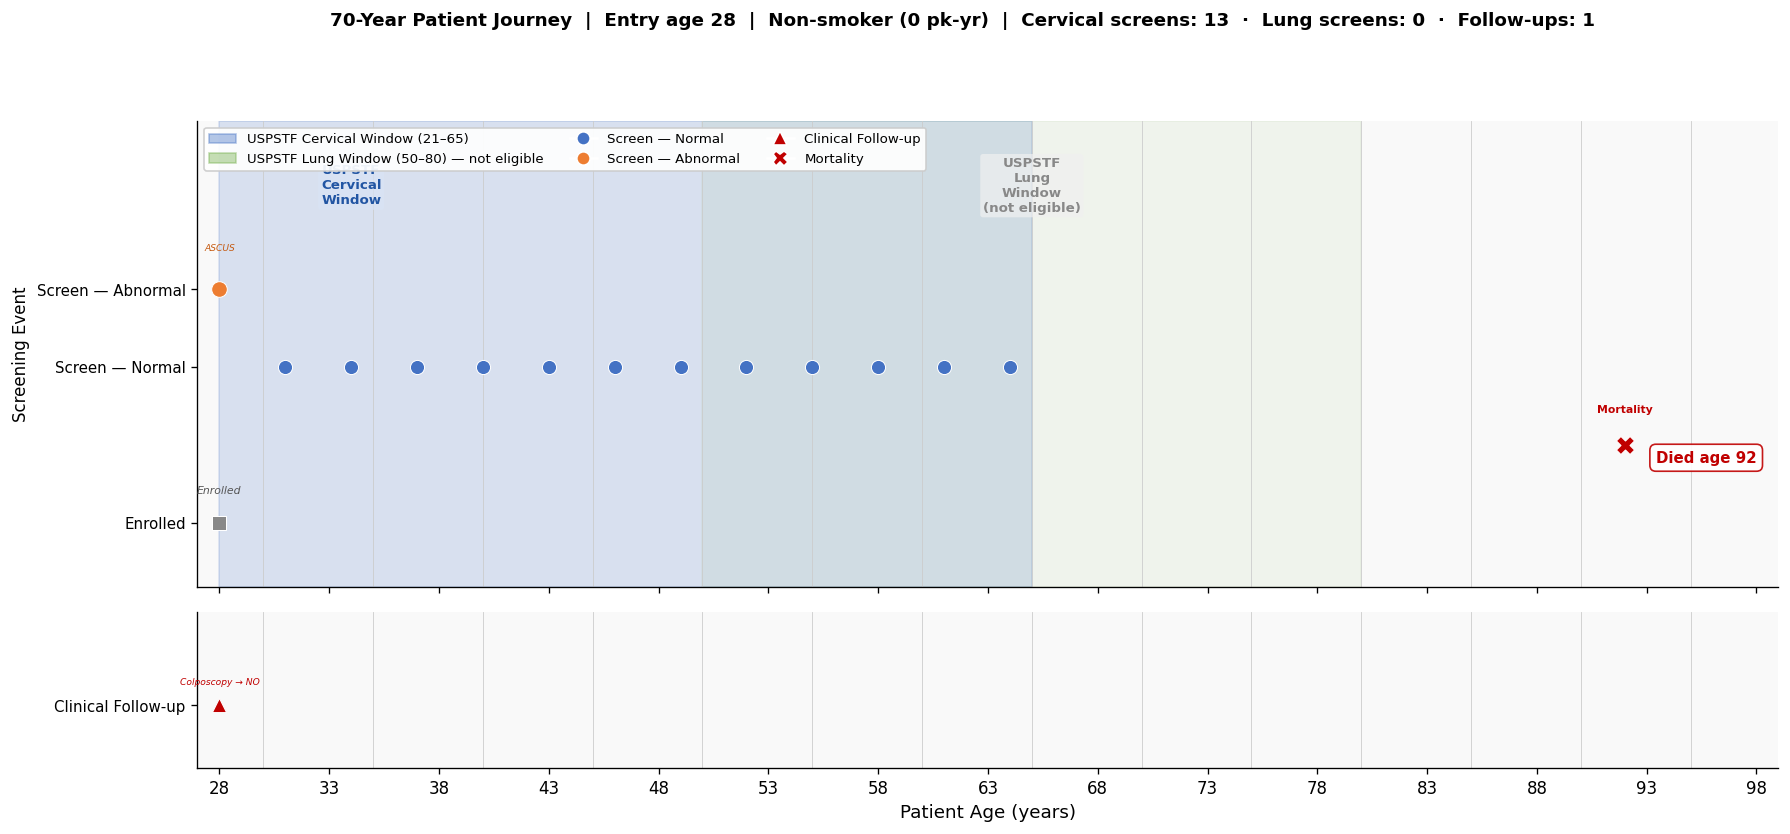

In [6]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PATIENT TRACE  — USPSTF Screening Windows & Outcome
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Both USPSTF eligibility windows are always shown (pulled from cfg.ELIGIBILITY):
#   - Cervical (blue):  age range from config (for patients with a cervix)
#   - Lung (green):     age range from config (for smokers ≥min_pack_years)
# If the patient is ineligible for a window (e.g. non-smoker), the band is
# still drawn but dimmed and labelled "not eligible".

cerv_elig = cfg.ELIGIBILITY["cervical"]
lung_elig = cfg.ELIGIBILITY["lung"]

entry_pk = getattr(patient, "_entry_pack_years", patient.pack_years)
outcome_str = (
    f"Died age {patient.age}" if patient.exit_reason == "mortality"
    else f"Alive at simulation end (age {patient.age})"
    if not patient.exit_reason
    else f"Lost to follow-up (age {patient.age})"
)
outcome_color = (
    "#C00000" if patient.exit_reason == "mortality"
    else "#70AD47" if not patient.exit_reason
    else "#FF8C00"
)

# ── collect events ────────────────────────────────────────────────────────
enroll_events, normal_events, abnormal_events, followup_events, mortality_events = [], [], [], [], []
for day, age, category, desc in timeline:
    if   category == "enrollment":     enroll_events.append((age, desc))
    elif category == "screen_normal":  normal_events.append((age, desc))
    elif category == "screen_abnormal":abnormal_events.append((age, desc))
    elif category in ("colposcopy", "treatment", "lung_followup"): followup_events.append((age, desc))
    elif category == "mortality":      mortality_events.append((age, desc))

# ── layout ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(17, 7))
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08, figure=fig)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

age_min = patient.age_at_entry
age_max = patient.age_at_entry + 71

for ax in (ax_top, ax_bot):
    ax.set_facecolor("#f9f9f9")
    ax.set_xlim(age_min - 1, age_max)
    for decade in range(25, age_max, 5):
        ax.axvline(decade, color="#cccccc", linewidth=0.5, zorder=1)

# ── USPSTF eligibility windows (from config; always shown; dimmed if ineligible)
cerv_start = max(cerv_elig["age_min"], age_min)
cerv_end   = min(cerv_elig["age_max"], age_max)
lung_start = max(lung_elig["age_min"], age_min)
lung_end   = min(lung_elig["age_max"], age_max)

# Cervical window
cerv_applicable = patient.has_cervix if cerv_elig.get("requires_cervix") else True
if cerv_applicable and cerv_start < cerv_end:
    ax_top.axvspan(cerv_start, cerv_end, alpha=0.18, color="#4472C4", zorder=0)
    ax_top.annotate("USPSTF\nCervical\nWindow",
                    xy=((cerv_start + min(cerv_end, cerv_start + 12)) / 2, 2.6),
                    fontsize=8, color="#2155A3", ha="center", va="center", fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", fc="#d9e4f5", ec="none", alpha=0.7))

# Lung window — always shown; dimmed + labelled "not eligible" for non-smokers
min_pk = lung_elig.get("min_pack_years", 20)
lung_is_eligible = patient.smoker and entry_pk >= min_pk
lung_alpha = 0.15 if lung_is_eligible else 0.07
if lung_start < lung_end:
    ax_top.axvspan(lung_start, lung_end, alpha=lung_alpha, color="#70AD47", zorder=0)
    lung_label = "USPSTF\nLung\nWindow"
    if not lung_is_eligible:
        lung_label += "\n(not eligible)"
    label_color = "#375623" if lung_is_eligible else "#888888"
    ax_top.annotate(lung_label,
                    xy=((lung_start + lung_end) / 2, 2.6),
                    fontsize=8, color=label_color, ha="center", va="center", fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2",
                              fc="#e2efd9" if lung_is_eligible else "#f0f0f0",
                              ec="none", alpha=0.7))

# ── top panel: screening events on 3 y-lanes ─────────────────────────────
for age, desc in enroll_events:
    ax_top.scatter(age, 0, color="#888888", marker="s", s=64, zorder=5, edgecolors="white", lw=0.6)
    ax_top.text(age, 0.22, "Enrolled", fontsize=6.5, ha="center", color="#555555", style="italic")

for age, desc in normal_events:
    ax_top.scatter(age, 1.2, color="#4472C4", marker="o", s=72, zorder=5, edgecolors="white", lw=0.6)

for age, desc in abnormal_events:
    ax_top.scatter(age, 1.8, color="#ED7D31", marker="o", s=88, zorder=5, edgecolors="white", lw=0.6)
    short = desc.split(":")[1].strip() if ":" in desc else desc[:18]
    ax_top.text(age, 2.1, short, fontsize=5.5, ha="center", color="#C55A11", style="italic")

for age, desc in mortality_events:
    ax_top.scatter(age, 0.6, color="#C00000", marker="X", s=120, zorder=6, edgecolors="white", lw=0.7)
    ax_top.text(age, 0.85, "Mortality", fontsize=6.5, ha="center", color="#C00000", fontweight="bold")

# outcome annotation (right edge)
ax_top.annotate(
    outcome_str,
    xy=(age_max - 1, 0.5), xytext=(age_max - 1, 0.5),
    fontsize=9, ha="right", va="center", color=outcome_color, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=outcome_color, alpha=0.9)
)

# ── top panel formatting ─────────────────────────────────────────────────
ax_top.set_yticks([0, 1.2, 1.8])
ax_top.set_yticklabels(["Enrolled", "Screen — Normal", "Screen — Abnormal"], fontsize=9)
ax_top.set_ylim(-0.5, 3.1)
ax_top.tick_params(labelbottom=False)
ax_top.set_ylabel("Screening Event", fontsize=10)

# ── bottom panel: clinical follow-up ─────────────────────────────────────
for age, desc in followup_events:
    ax_bot.scatter(age, 0, color="#C00000", marker="^", s=72, zorder=5, edgecolors="white", lw=0.6)
    short = desc.split(":")[1].strip() if ":" in desc else desc[:15]
    ax_bot.text(age, 0.2, short, fontsize=5.5, ha="center", color="#C00000", style="italic")

ax_bot.set_yticks([0])
ax_bot.set_yticklabels(["Clinical Follow-up"], fontsize=9)
ax_bot.set_ylim(-0.6, 0.9)
ax_bot.set_xlabel("Patient Age (years)", fontsize=11)
ax_bot.set_xticks(range(int(age_min), int(age_max), 5))

# ── legend ───────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color="#4472C4", alpha=0.4,
                   label=f"USPSTF Cervical Window ({cerv_elig['age_min']}–{cerv_elig['age_max']})"),
    mpatches.Patch(color="#70AD47", alpha=0.4,
                   label=f"USPSTF Lung Window ({lung_elig['age_min']}–{lung_elig['age_max']})"
                         f"{'' if lung_is_eligible else ' — not eligible'}"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#4472C4", markersize=8, label="Screen — Normal"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#ED7D31", markersize=8, label="Screen — Abnormal"),
    plt.Line2D([0], [0], marker="^", color="w", markerfacecolor="#C00000", markersize=8, label="Clinical Follow-up"),
    plt.Line2D([0], [0], marker="X", color="w", markerfacecolor="#C00000", markersize=9, label="Mortality"),
]
ax_top.legend(handles=legend_handles, loc="upper left", fontsize=8, framealpha=0.92, ncol=3)

# ── title ─────────────────────────────────────────────────────────────────
fig.suptitle(
    f"70-Year Patient Journey  |  Entry age {patient.age_at_entry}  |  "
    f"{'Smoker' if patient.smoker else 'Non-smoker'} ({entry_pk:.0f} pk-yr)  |  "
    f"Cervical screens: {pt_metrics['n_screened']['cervical']}  ·  "
    f"Lung screens: {pt_metrics['n_screened']['lung']}  ·  "
    f"Follow-ups: {pt_metrics['n_colposcopy'] + pt_metrics['n_treated']}",
    fontsize=11, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.show()


#### Patient Scheduling Detail

How long this patient waited between care steps. Each bar is the gap in days between two consecutive events. Long bars represent scheduling delays or periods between routine screens — the key inputs for calibrating wait time distributions against NYP data.

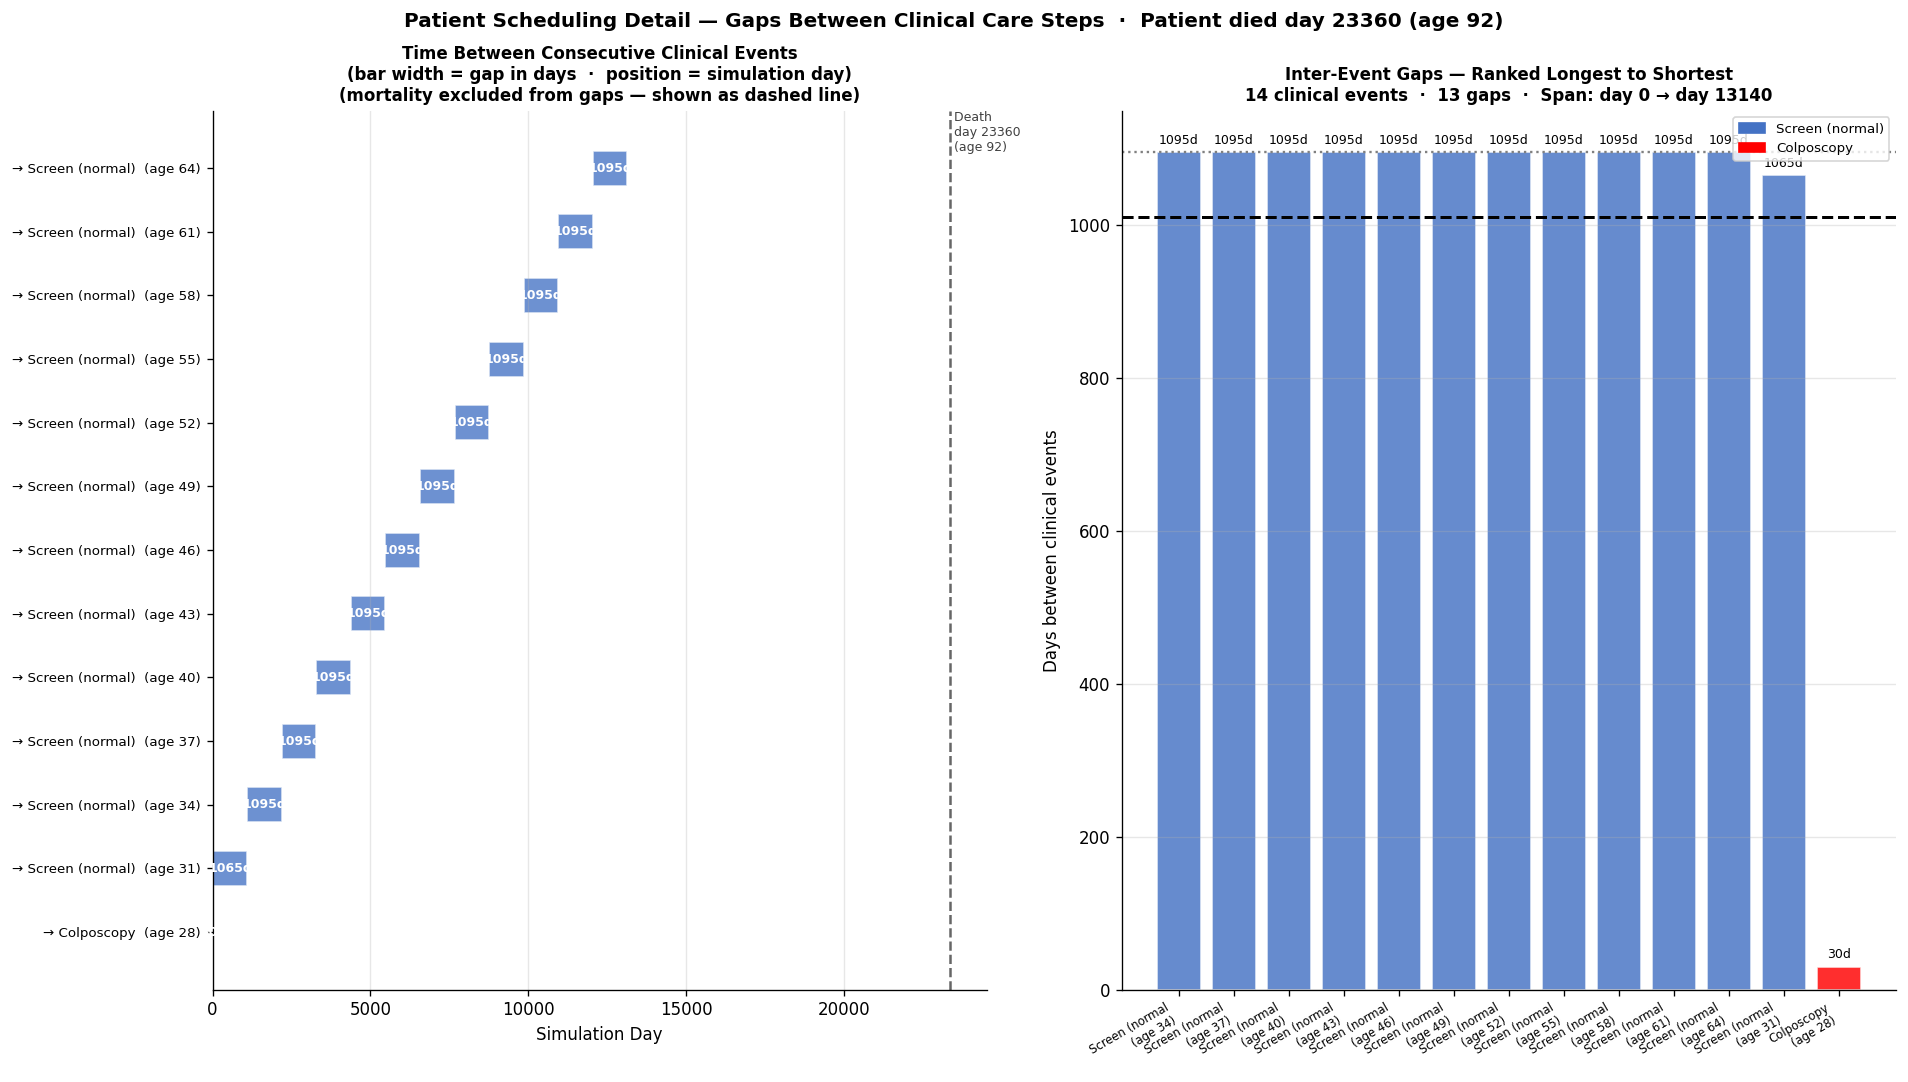


From → To                                      Gap (days)  Patient Age
------------------------------------------------------------------------
  Screen (abnormal)    → Colposcopy                    30  age 28
  Colposcopy           → Screen (normal)            1,065  age 31
  Screen (normal)      → Screen (normal)            1,095  age 34
  Screen (normal)      → Screen (normal)            1,095  age 37
  Screen (normal)      → Screen (normal)            1,095  age 40
  Screen (normal)      → Screen (normal)            1,095  age 43
  Screen (normal)      → Screen (normal)            1,095  age 46
  Screen (normal)      → Screen (normal)            1,095  age 49
  Screen (normal)      → Screen (normal)            1,095  age 52
  Screen (normal)      → Screen (normal)            1,095  age 55
  Screen (normal)      → Screen (normal)            1,095  age 58
  Screen (normal)      → Screen (normal)            1,095  age 61
  Screen (normal)      → Screen (normal)            1,095  age 

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Scheduling detail for single patient ─────────────────────────────────────
# Color / label maps for CLINICAL events only — mortality excluded from gaps
# because "time from last screen to death" is survival duration, not a care gap.
cat_colors = {
    'screen_normal':   '#4472C4',
    'screen_abnormal': '#ED7D31',
    'colposcopy':      '#FF0000',
    'treatment':       '#C00000',
    'lung_followup':   '#70AD47',
}
cat_labels = {
    'screen_normal':   'Screen (normal)',
    'screen_abnormal': 'Screen (abnormal)',
    'colposcopy':      'Colposcopy',
    'treatment':       'Treatment',
    'lung_followup':   'Lung follow-up',
}

# Pull clinical events only (mortality intentionally excluded)
care_events = [
    (day, age, cat, desc)
    for day, age, cat, desc in timeline
    if cat in cat_colors
]

# Find mortality event for annotation (if it exists) — shown separately
mortality_event = next(
    ((day, age) for day, age, cat, desc in timeline if cat == 'mortality'),
    None
)

if len(care_events) < 2:
    print("This patient had fewer than 2 recorded clinical care events — no scheduling gaps to show.")
    print(f"  Clinical events recorded: {len(care_events)}")
    if mortality_event:
        print(f"  Patient died on day {mortality_event[0]} (age {mortality_event[1]:.0f})")
else:
    gaps = [
        {
            "from_age":  care_events[i-1][1],
            "to_age":    care_events[i][1],
            "from_day":  care_events[i-1][0],
            "to_day":    care_events[i][0],
            "gap_days":  care_events[i][0] - care_events[i-1][0],
            "from_cat":  care_events[i-1][2],
            "to_cat":    care_events[i][2],
            "to_desc":   care_events[i][3],
        }
        for i in range(1, len(care_events))
    ]

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(gaps) * 0.55 + 2)))

    # ── Panel A: Gantt — simulation day on x-axis, gap width = days ───────────
    ax = axes[0]
    for i, g in enumerate(gaps):
        col = cat_colors.get(g['to_cat'], '#888')
        ax.barh(i, g['gap_days'], left=g['from_day'], height=0.55,
                color=col, alpha=0.78, edgecolor='white')
        mid_x = g['from_day'] + g['gap_days'] / 2
        ax.text(mid_x, i, f"{g['gap_days']}d",
                ha='center', va='center', fontsize=7.5, fontweight='bold', color='white')

    # Annotate mortality day as a vertical line if present
    if mortality_event:
        ax.axvline(mortality_event[0], color='black', lw=1.5, ls='--', alpha=0.6)
        ax.text(mortality_event[0], len(gaps) - 0.1,
                f" Death\n day {mortality_event[0]}\n (age {mortality_event[1]:.0f})",
                va='top', fontsize=7.5, color='black', alpha=0.75)

    y_labels = [
        f"→ {cat_labels.get(g['to_cat'], g['to_cat'])}  (age {g['to_age']:.0f})"
        for g in gaps
    ]
    ax.set_yticks(range(len(gaps)))
    ax.set_yticklabels(y_labels, fontsize=8)
    ax.set_xlabel('Simulation Day', fontsize=10)
    ax.set_title('Time Between Consecutive Clinical Events\n(bar width = gap in days  ·  position = simulation day)\n'
                 '(mortality excluded from gaps — shown as dashed line)',
                 fontweight='bold', fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    # ── Panel B: Gap lengths ranked — clinical events only ────────────────────
    ax2 = axes[1]
    sorted_gaps = sorted(gaps, key=lambda g: -g['gap_days'])
    gap_days  = [g['gap_days']  for g in sorted_gaps]
    gap_cols  = [cat_colors.get(g['to_cat'], '#888') for g in sorted_gaps]
    gap_xlbls = [
        f"{cat_labels.get(g['to_cat'], g['to_cat'])[:14]}\n(age {g['to_age']:.0f})"
        for g in sorted_gaps
    ]

    bars = ax2.bar(range(len(gap_days)), gap_days, color=gap_cols, alpha=0.82, edgecolor='white')
    ax2.axhline(np.mean(gap_days), color='black', linewidth=1.8, linestyle='--',
                label=f'Mean gap: {np.mean(gap_days):.0f}d')
    ax2.axhline(np.median(gap_days), color='gray', linewidth=1.4, linestyle=':',
                label=f'Median gap: {np.median(gap_days):.0f}d')
    for bar, val in zip(bars, gap_days):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(gap_days) * 0.01,
                 f'{val}d', ha='center', fontsize=7.5)
    ax2.set_xticks(range(len(gap_xlbls)))
    ax2.set_xticklabels(gap_xlbls, fontsize=7, rotation=30, ha='right')
    ax2.set_ylabel('Days between clinical events')
    ax2.set_title(
        f'Inter-Event Gaps — Ranked Longest to Shortest\n'
        f'{len(care_events)} clinical events  ·  {len(gaps)} gaps  ·  '
        f'Span: day {care_events[0][0]} → day {care_events[-1][0]}',
        fontweight='bold', fontsize=10)
    ax2.grid(axis='y', alpha=0.3)
    ax2.spines[['top', 'right']].set_visible(False)

    # Legend
    legend_patches = [
        mpatches.Patch(color=col, label=cat_labels[cat])
        for cat, col in cat_colors.items()
        if any(g['to_cat'] == cat for g in gaps)
    ]
    ax2.legend(handles=legend_patches, fontsize=8, loc='upper right')

    # Suptitle includes mortality note if present
    mort_note = (f"  ·  Patient died day {mortality_event[0]} (age {mortality_event[1]:.0f})"
                 if mortality_event else "")
    plt.suptitle(f'Patient Scheduling Detail — Gaps Between Clinical Care Steps{mort_note}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n{'From → To':<45} {'Gap (days)':>11} {'Patient Age':>12}")
    print("-" * 72)
    for g in gaps:
        frm = cat_labels.get(g['from_cat'], g['from_cat'])
        to  = cat_labels.get(g['to_cat'],   g['to_cat'])
        print(f"  {frm:<20} → {to:<20} {g['gap_days']:>11,}  age {g['to_age']:.0f}")
    if mortality_event:
        last_care_day = care_events[-1][0]
        surv = mortality_event[0] - last_care_day
        print(f"\n  Survival after last clinical event: {surv:,} days  "
              f"({surv/365:.1f} yr)  — not a care gap")


---

## Longitudinal Visualizations

How the screening program performs year by year across the 70-year horizon.

| Chart | What it shows |
|---|---|
| **Screening Volume Over Time** | Annual cervical and lung screening throughput, with LTFU and pool stability |
| **Clinical Rates Over Time** | How screening, abnormal result, and completion rates evolve across the simulation |
| **Revenue Over Time** | Annual realized revenue by procedure type, cumulative total, and LTFU lost revenue |
| **Patient Journey Cascade** | Cumulative 70-year funnel from provider visit to treatment |
| **Lung Cancer Pathway** | Attrition from eligible smoker to treatment, with RADS distribution |
| **Population Dynamics** | Pool stability, annual throughput, and provider capacity |

### Individual Charts

Each chart below produces a **single image** saved to `Base Visualizations/`.


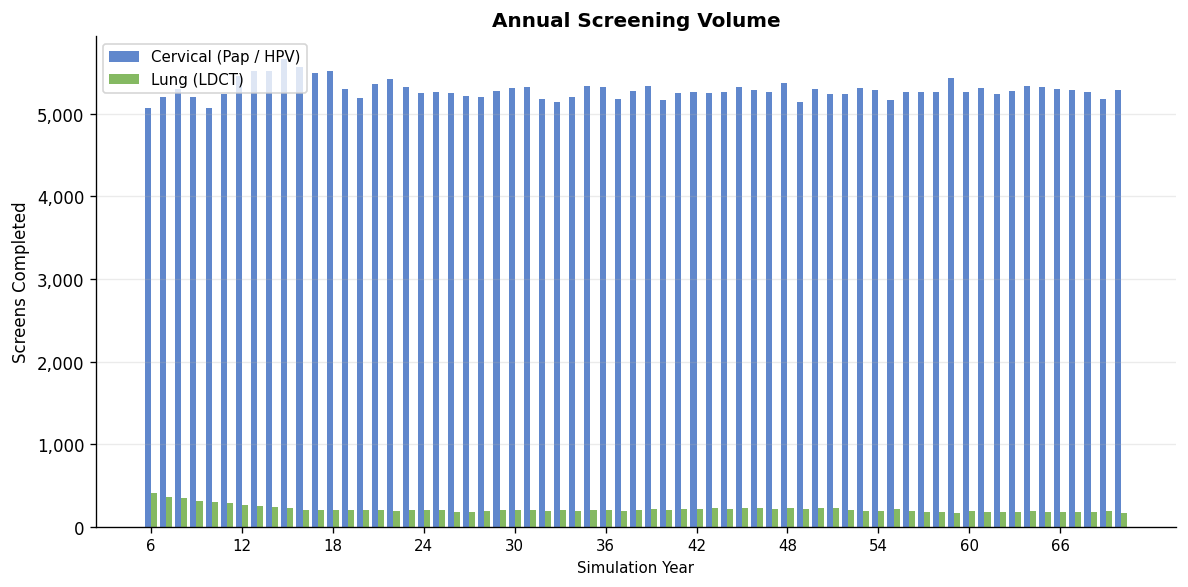

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = m.get("year_checkpoints", [])
years = [c["year"] for c in chk]

warmup_yrs = cfg.WARMUP_DAYS // 365

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

ann_cerv = ann("cum_cervical")
ann_lung = ann("cum_lung")

# Strip warmup years
years_ss = years[warmup_yrs:]
cerv_ss  = ann_cerv[warmup_yrs:]
lung_ss  = ann_lung[warmup_yrs:]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
x     = np.arange(len(years_ss))
bar_w = 0.4
ax.bar(x - bar_w/2, cerv_ss, bar_w, color="#4472C4", alpha=0.85, label="Cervical (Pap / HPV)")
ax.bar(x + bar_w/2, lung_ss, bar_w, color="#70AD47", alpha=0.85, label="Lung (LDCT)")
tick_step = max(1, len(years_ss) // 10)
ax.set_xticks(x[::tick_step])
ax.set_xticklabels([str(y) for y in years_ss[::tick_step]], fontsize=9)
ax.set_xlabel("Simulation Year", fontsize=9)
ax.set_ylabel("Screens Completed", fontsize=10)
ax.set_title("Annual Screening Volume", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "01_annual_screening_volume.png"), dpi=150, bbox_inches="tight")
plt.show()

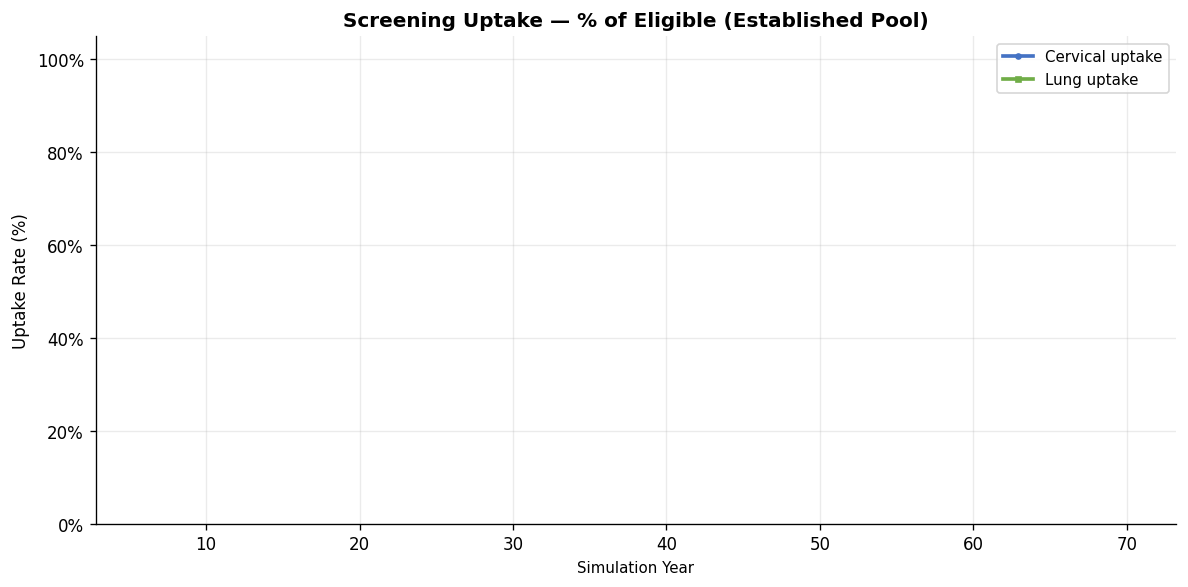

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.ticker as mtick
import numpy as np
import config as cfg

m   = metrics_70yr
chk = m.get("year_checkpoints", [])
years = [c["year"] for c in chk]

warmup_yrs = cfg.WARMUP_DAYS // 365

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

# Use established-pool-only screening counts so organic drop-ins
# (who aren't part of the denominator) don't inflate the ratio.
ann_cerv  = ann("cum_cervical_est")[warmup_yrs:]
ann_lung  = ann("cum_lung_est")[warmup_yrs:]
pool_size = [c["pool_size"] for c in chk][warmup_yrs:]
years_ss  = years[warmup_yrs:]

eligible_cerv = [p * 0.62 for p in pool_size]
eligible_lung = [p * 0.10 for p in pool_size]
uptake_cerv = [100 * c / max(e, 1) for c, e in zip(ann_cerv, eligible_cerv)]
uptake_lung = [100 * l / max(e, 1) for l, e in zip(ann_lung, eligible_lung)]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.plot(years_ss, uptake_cerv, color="#4472C4", lw=2.2, marker="o", markersize=3, label="Cervical uptake")
ax.plot(years_ss, uptake_lung, color="#70AD47", lw=2.2, marker="s", markersize=3, label="Lung uptake")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Simulation Year", fontsize=9)
ax.set_ylabel("Uptake Rate (%)", fontsize=10)
ax.set_title("Screening Uptake — % of Eligible (Established Pool)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "02_screening_uptake.png"), dpi=150, bbox_inches="tight")
plt.show()

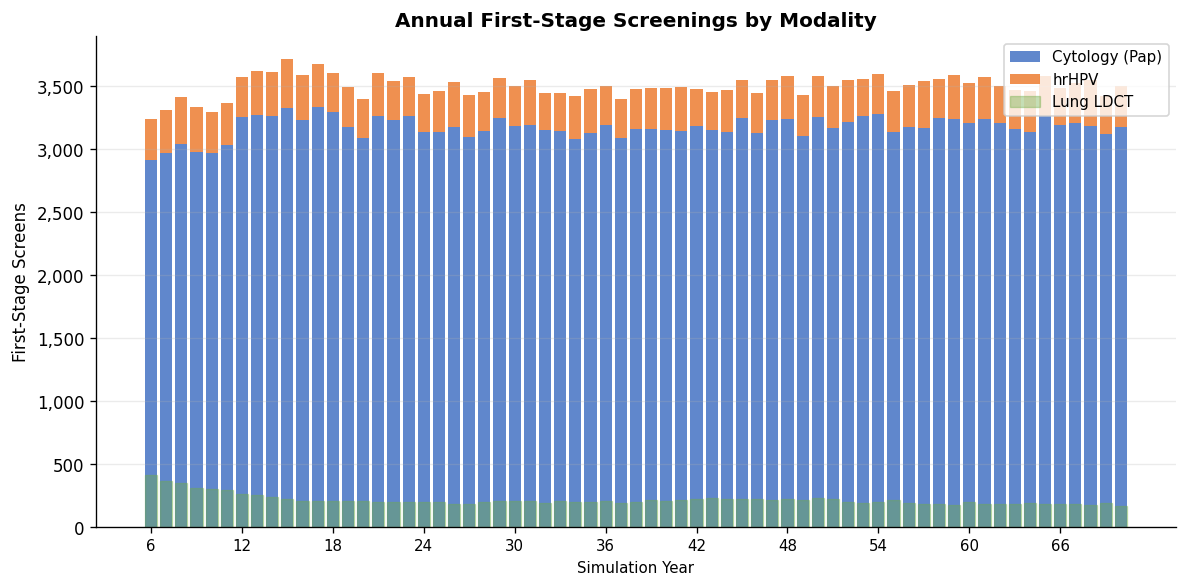

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = m.get("year_checkpoints", [])
years = [c["year"] for c in chk]

warmup_yrs = cfg.WARMUP_DAYS // 365

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

# Annual first-stage screenings by test modality (skip warmup)
ann_cyto = ann("cum_cytology")[warmup_yrs:]
ann_hpv  = ann("cum_hpv_alone")[warmup_yrs:]
ann_ldct = ann("cum_ldct")[warmup_yrs:]
years_ss = years[warmup_yrs:]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
x = np.arange(len(years_ss))

# Stacked cervical: cytology on bottom, hrHPV on top
ax.bar(x, ann_cyto, color="#4472C4", alpha=0.85, label="Cytology (Pap)")
ax.bar(x, ann_hpv, bottom=ann_cyto, color="#ED7D31", alpha=0.85, label="hrHPV")
# LDCT as separate grouped bar
ax.bar(x, ann_ldct, color="#70AD47", alpha=0.40, edgecolor="#70AD47", lw=0.8, label="Lung LDCT")

tick_step = max(1, len(years_ss) // 10)
ax.set_xticks(x[::tick_step])
ax.set_xticklabels([str(y) for y in years_ss[::tick_step]], fontsize=9)
ax.set_xlabel("Simulation Year", fontsize=9)
ax.set_ylabel("First-Stage Screens", fontsize=10)
ax.set_title("Annual First-Stage Screenings by Modality", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "03_first_stage_screenings.png"), dpi=150, bbox_inches="tight")
plt.show()

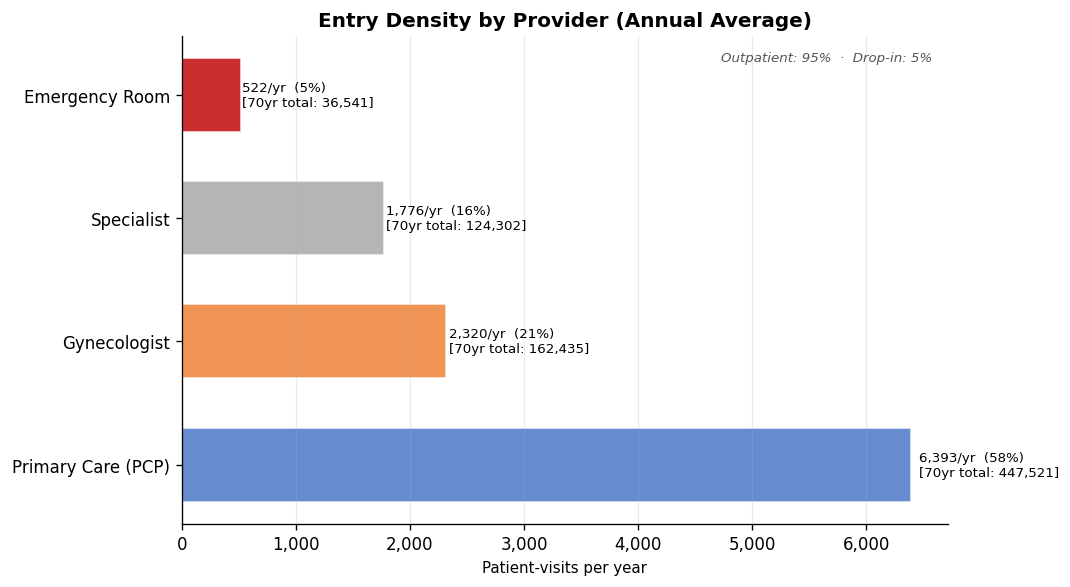

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import config as cfg

m = metrics_70yr
sim_years = cfg.SIM_YEARS

dest_counts = dict(m.get("entries_by_destination", {}))
type_counts = dict(m.get("entries_by_type", {}))

dest_order  = ["pcp", "gynecologist", "specialist", "er"]
dest_labels = {"pcp": "Primary Care (PCP)", "gynecologist": "Gynecologist",
               "specialist": "Specialist", "er": "Emergency Room"}
dest_colors = {"pcp": "#4472C4", "gynecologist": "#ED7D31", "specialist": "#A5A5A5", "er": "#C00000"}

total_op     = type_counts.get("outpatient", 0)
total_dropin = type_counts.get("drop_in", 0)
total_type   = max(total_op + total_dropin, 1)

ann_by_dest = {d: dest_counts.get(d, 0) / sim_years for d in dest_order if dest_counts.get(d, 0) > 0}

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")
if ann_by_dest:
    dests  = [d for d in dest_order if d in ann_by_dest]
    counts = [ann_by_dest[d] for d in dests]
    lbls   = [dest_labels[d] for d in dests]
    colors = [dest_colors[d] for d in dests]
    bars   = ax.barh(range(len(dests)), counts, color=colors, alpha=0.82, edgecolor="white", height=0.6)
    ax.set_yticks(range(len(dests)))
    ax.set_yticklabels(lbls, fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    total_ann = sum(counts)
    for bar, val, d in zip(bars, counts, dests):
        raw70 = dest_counts.get(d, 0)
        pct   = 100 * val / max(total_ann, 1)
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f"{val:,.0f}/yr  ({pct:.0f}%)\n[70yr total: {raw70:,}]", va="center", fontsize=8)
    ax.text(0.98, 0.97,
            f"Outpatient: {total_op/total_type:.0%}  ·  Drop-in: {total_dropin/total_type:.0%}",
            transform=ax.transAxes, fontsize=8, ha="right", va="top", color="#555", style="italic")
ax.set_title("Entry Density by Provider (Annual Average)", fontsize=12, fontweight="bold")
ax.set_xlabel("Patient-visits per year", fontsize=9)
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "04_entry_density.png"), dpi=150, bbox_inches="tight")
plt.show()


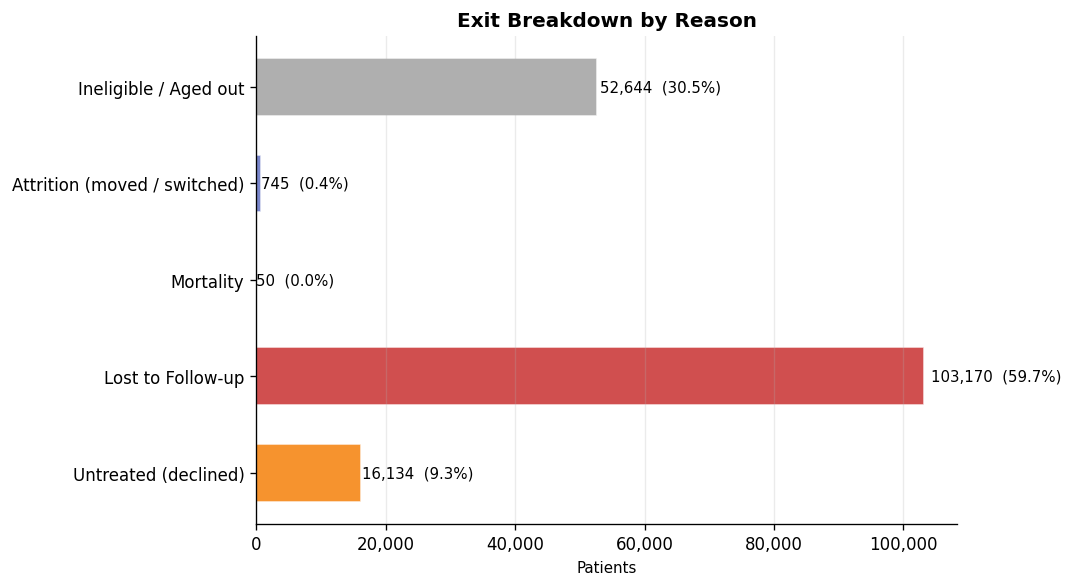

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

m = metrics_70yr
exit_counts = dict(m.get("exits_by_reason", {}))
exit_order  = ["treated", "untreated", "lost_to_followup", "mortality", "attrition", "ineligible"]
exit_labels = {"treated": "Treated (completed care)", "untreated": "Untreated (declined)",
               "lost_to_followup": "Lost to Follow-up", "mortality": "Mortality",
               "attrition": "Attrition (moved / switched)",
               "ineligible": "Ineligible / Aged out"}
exit_colors = {"treated": "#2E7D32", "untreated": "#F57C00", "lost_to_followup": "#C62828",
               "mortality": "#424242", "attrition": "#5C6BC0",
               "ineligible": "#9E9E9E"}

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")
if exit_counts:
    reasons = [r for r in exit_order if exit_counts.get(r, 0) > 0]
    vals    = [exit_counts[r] for r in reasons]
    lbls    = [exit_labels.get(r, r) for r in reasons]
    colors  = [exit_colors.get(r, "#BDBDBD") for r in reasons]
    bars    = ax.barh(range(len(reasons)), vals, color=colors, alpha=0.82, edgecolor="white", height=0.6)
    ax.set_yticks(range(len(reasons)))
    ax.set_yticklabels(lbls, fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    total_exits = sum(vals)
    for bar, val in zip(bars, vals):
        pct = 100 * val / max(total_exits, 1)
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f"{val:,}  ({pct:.1f}%)", va="center", fontsize=9)
ax.set_title("Exit Breakdown by Reason", fontsize=12, fontweight="bold")
ax.set_xlabel("Patients", fontsize=9)
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "05_exit_breakdown.png"), dpi=150, bbox_inches="tight")
plt.show()

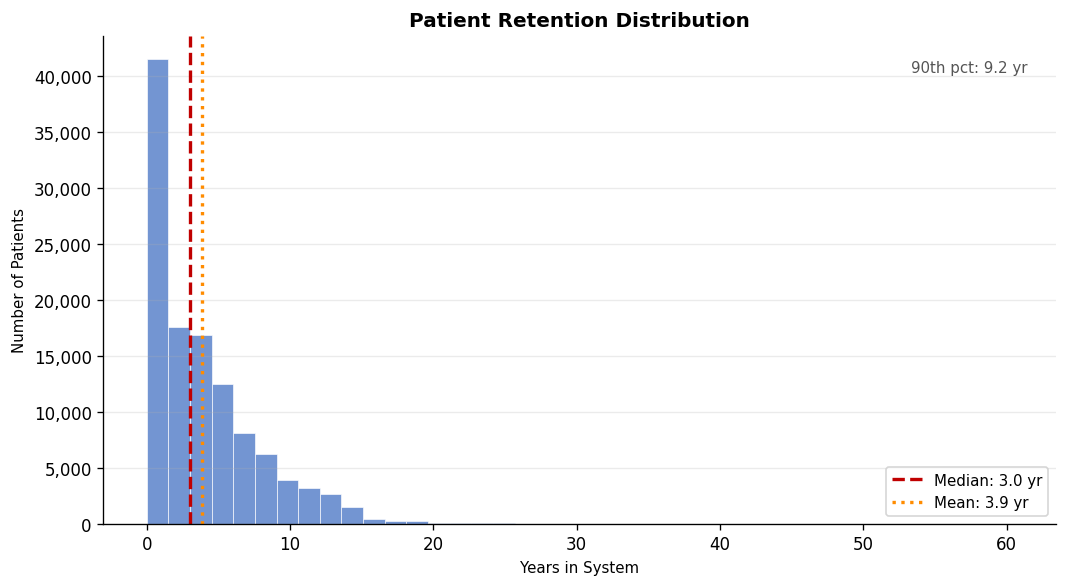

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

retention_days = metrics_70yr.get("days_in_system", [])

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")
if retention_days:
    retention_yrs = [d / 365 for d in retention_days]
    ax.hist(retention_yrs, bins=40, color="#4472C4", alpha=0.75, edgecolor="white", lw=0.5)
    median_yrs = np.median(retention_yrs)
    mean_yrs   = np.mean(retention_yrs)
    p90        = np.percentile(retention_yrs, 90)
    ax.axvline(median_yrs, color="#C00000", lw=2, ls="--", label=f"Median: {median_yrs:.1f} yr")
    ax.axvline(mean_yrs,   color="#FF8C00", lw=2, ls=":",  label=f"Mean: {mean_yrs:.1f} yr")
    ax.legend(fontsize=9)
    ax.set_xlabel("Years in System", fontsize=9)
    ax.set_ylabel("Number of Patients", fontsize=9)
    ax.text(0.97, 0.95, f"90th pct: {p90:.1f} yr",
            transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#555")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_title("Patient Retention Distribution", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "06_retention.png"), dpi=150, bbox_inches="tight")
plt.show()


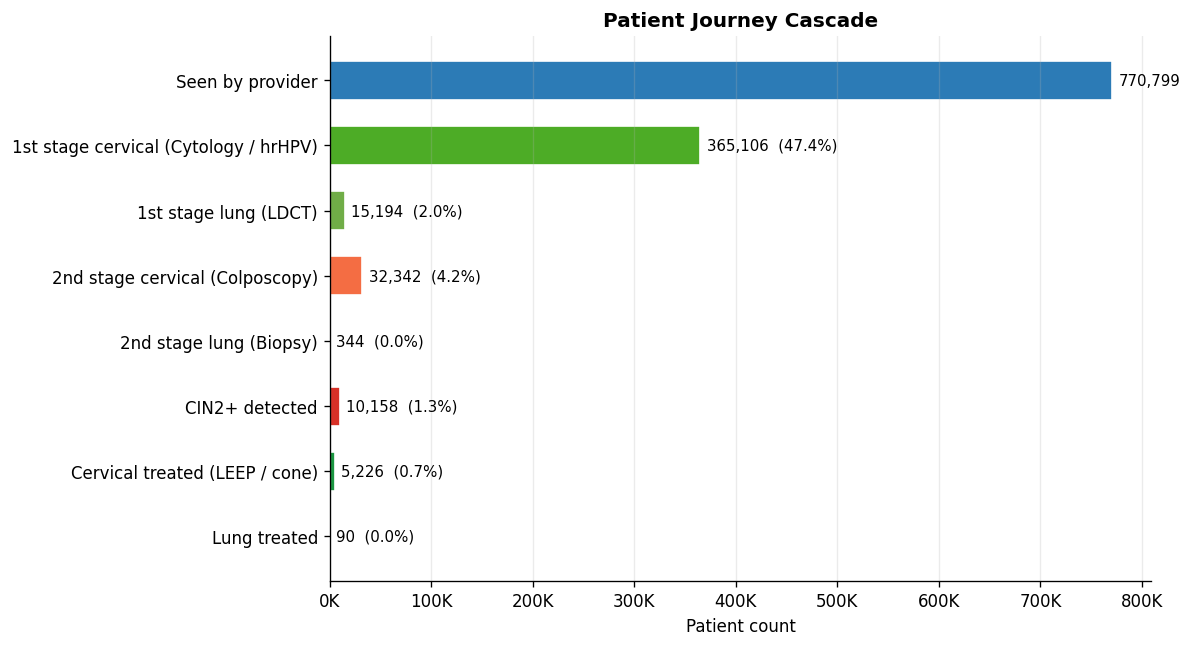

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import config as cfg

m = metrics_70yr
total_seen    = m["n_patients"]

# 1st stage screening
cerv_screened = m["n_screened"]["cervical"]
lung_screened = m["n_screened"]["lung"]

# 2nd stage — cervical: colposcopy; lung: biopsy
colposcopies       = m["n_colposcopy"]
lung_biopsy_done   = m.get("lung_biopsy_completed", 0)

# Downstream
cin2_plus     = m["colposcopy_results"].get("CIN2", 0) + m["colposcopy_results"].get("CIN3", 0)
treated       = m["n_treated"]
lung_treated  = m.get("lung_treatment_given", 0)

labels = [
    "Seen by provider",
    "1st stage cervical (Cytology / hrHPV)",
    "1st stage lung (LDCT)",
    "2nd stage cervical (Colposcopy)",
    "2nd stage lung (Biopsy)",
    "CIN2+ detected",
    "Cervical treated (LEEP / cone)",
    "Lung treated",
]
values = [
    total_seen,
    cerv_screened,
    lung_screened,
    colposcopies,
    lung_biopsy_done,
    cin2_plus,
    treated,
    lung_treated,
]
colors = ["#2c7bb6", "#4dac26", "#70AD47",
          "#f46d43", "#fdae61",
          "#d73027", "#1a9641", "#1a7a5a"]

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor("white")
y_pos = np.arange(len(labels))
bars  = ax.barh(y_pos, values, color=colors, edgecolor="white", height=0.6)

for i, (bar, val) in enumerate(zip(bars, values)):
    pct = f"  ({100*val/total_seen:.1f}%)" if i > 0 else ""
    ax.text(bar.get_width() + total_seen * 0.008, bar.get_y() + bar.get_height()/2,
            f"{val:,}{pct}", va="center", ha="left", fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Patient count", fontsize=10)
ax.set_title("Patient Journey Cascade", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "07_patient_cascade.png"), dpi=150, bbox_inches="tight")
plt.show()

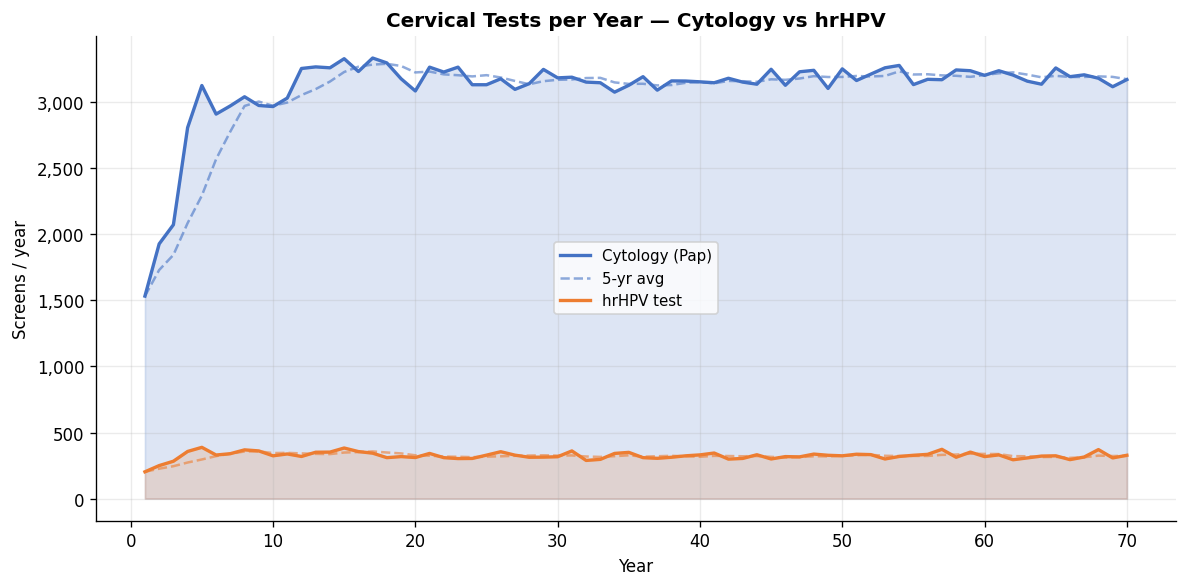

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = m.get("year_checkpoints", [])
years = [c["year"] for c in chk]

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

def rolling_avg(series, w=5):
    out = []
    for i in range(len(series)):
        window = series[max(0, i-w+1):i+1]
        out.append(sum(window) / len(window))
    return out

ann_cytol = ann("cum_cytology")
ann_hpv   = ann("cum_hpv_alone")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.fill_between(years, ann_cytol, alpha=0.18, color="#4472C4")
ax.plot(years, ann_cytol, color="#4472C4", lw=2, label="Cytology (Pap)")
ax.plot(years, rolling_avg(ann_cytol), color="#4472C4", lw=1.5, ls="--", alpha=0.6, label="5-yr avg")
ax.fill_between(years, ann_hpv, alpha=0.18, color="#ED7D31")
ax.plot(years, ann_hpv, color="#ED7D31", lw=2, label="hrHPV test")
ax.plot(years, rolling_avg(ann_hpv), color="#ED7D31", lw=1.5, ls="--", alpha=0.6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_title("Cervical Tests per Year — Cytology vs hrHPV", fontsize=12, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Screens / year")
ax.legend(fontsize=9)
ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "08_cervical_tests_by_type.png"), dpi=150, bbox_inches="tight")
plt.show()


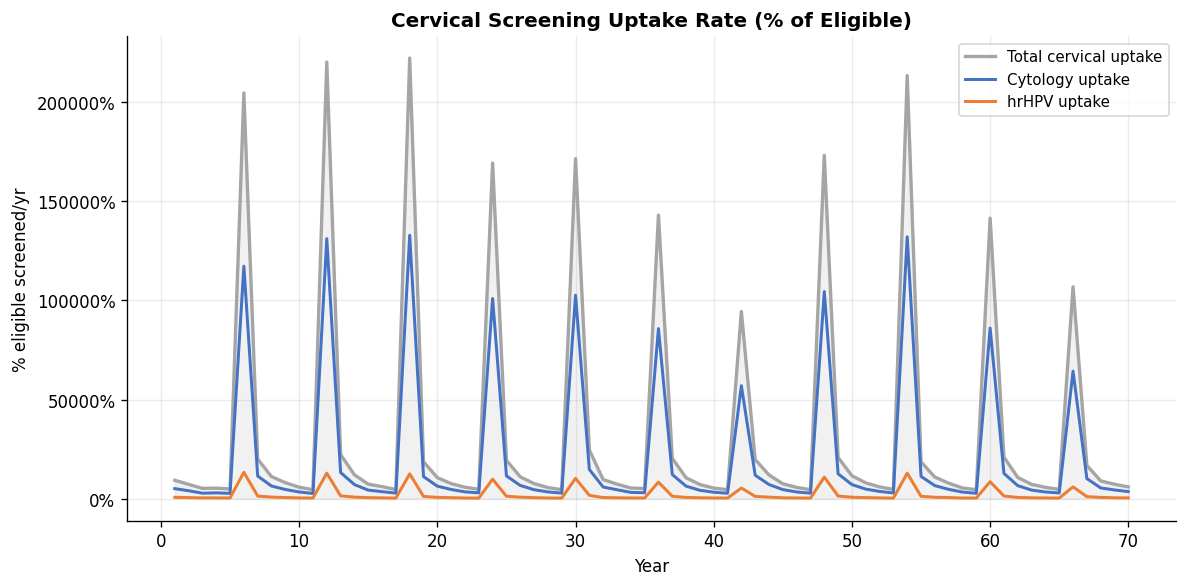

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.ticker as mtick
import numpy as np
import config as cfg

m   = metrics_70yr
chk = m.get("year_checkpoints", [])
years = [c["year"] for c in chk]

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

ann_cytol = ann("cum_cytology")
ann_hpv   = ann("cum_hpv_alone")
ann_cerv  = ann("cum_cervical")
pool_size = [c["pool_size"] for c in chk]
cerv_elig = [max(p * 0.62, 1) for p in pool_size]

cytol_rate = [100 * c / e for c, e in zip(ann_cytol, cerv_elig)]
hpv_rate   = [100 * h / e for h, e in zip(ann_hpv, cerv_elig)]
cerv_rate  = [100 * c / e for c, e in zip(ann_cerv, cerv_elig)]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.fill_between(years, cerv_rate, alpha=0.15, color="#A5A5A5")
ax.plot(years, cerv_rate, color="#A5A5A5", lw=2, label="Total cervical uptake")
ax.plot(years, cytol_rate, color="#4472C4", lw=1.8, label="Cytology uptake")
ax.plot(years, hpv_rate, color="#ED7D31", lw=1.8, label="hrHPV uptake")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Cervical Screening Uptake Rate (% of Eligible)", fontsize=12, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("% eligible screened/yr")
ax.legend(fontsize=9); ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "09_cervical_uptake_rate.png"), dpi=150, bbox_inches="tight")
plt.show()

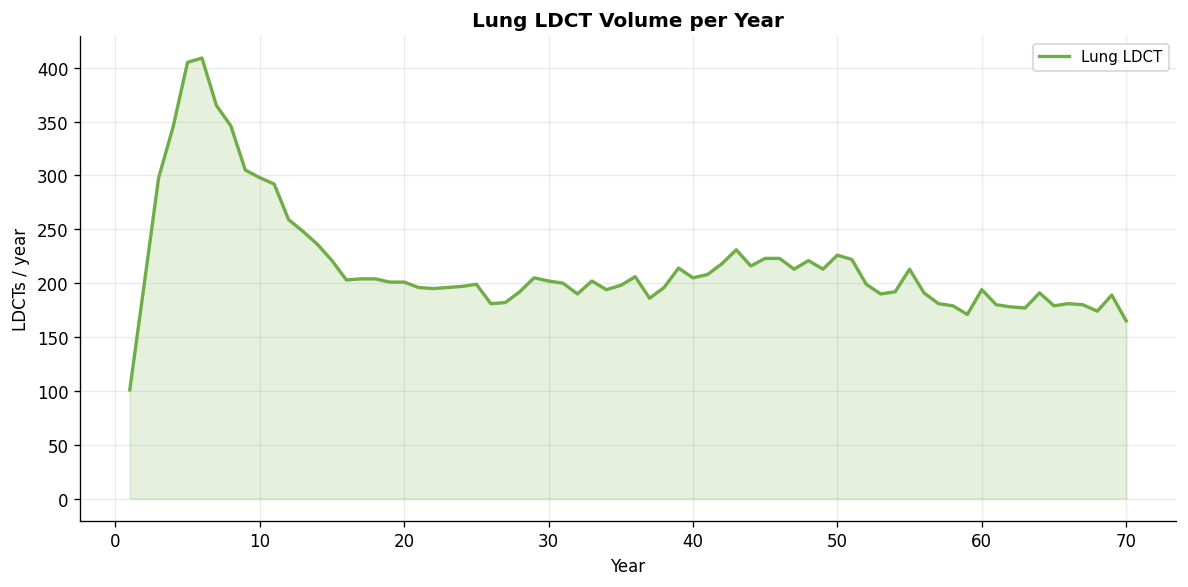

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = m.get("year_checkpoints", [])
years = [c["year"] for c in chk]

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

ann_ldct = ann("cum_ldct")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.fill_between(years, ann_ldct, alpha=0.18, color="#70AD47")
ax.plot(years, ann_ldct, color="#70AD47", lw=2, label="Lung LDCT")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_title("Lung LDCT Volume per Year", fontsize=12, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("LDCTs / year")
ax.legend(fontsize=9); ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "10_lung_ldct_volume.png"), dpi=150, bbox_inches="tight")
plt.show()

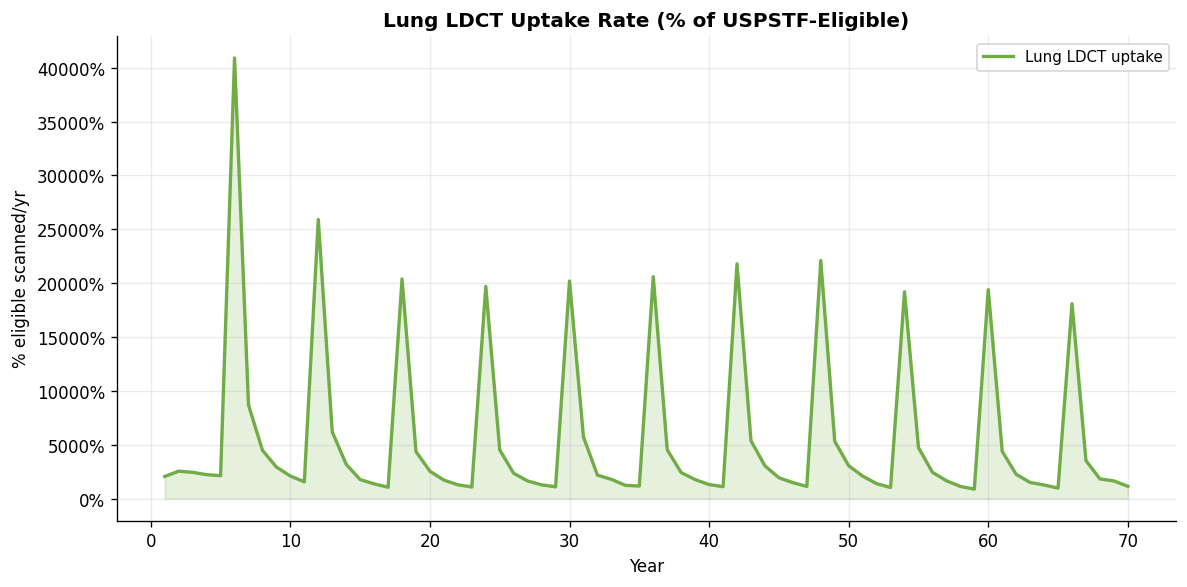

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.ticker as mtick
import numpy as np
import config as cfg

m   = metrics_70yr
chk = m.get("year_checkpoints", [])
years = [c["year"] for c in chk]

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

ann_ldct  = ann("cum_ldct")
pool_size = [c["pool_size"] for c in chk]
lung_elig = [max(p * 0.10, 1) for p in pool_size]
lung_rate = [100 * l / e for l, e in zip(ann_ldct, lung_elig)]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.fill_between(years, lung_rate, alpha=0.18, color="#70AD47")
ax.plot(years, lung_rate, color="#70AD47", lw=2, label="Lung LDCT uptake")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Lung LDCT Uptake Rate (% of USPSTF-Eligible)", fontsize=12, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("% eligible scanned/yr")
ax.legend(fontsize=9); ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "11_lung_uptake_rate.png"), dpi=150, bbox_inches="tight")
plt.show()

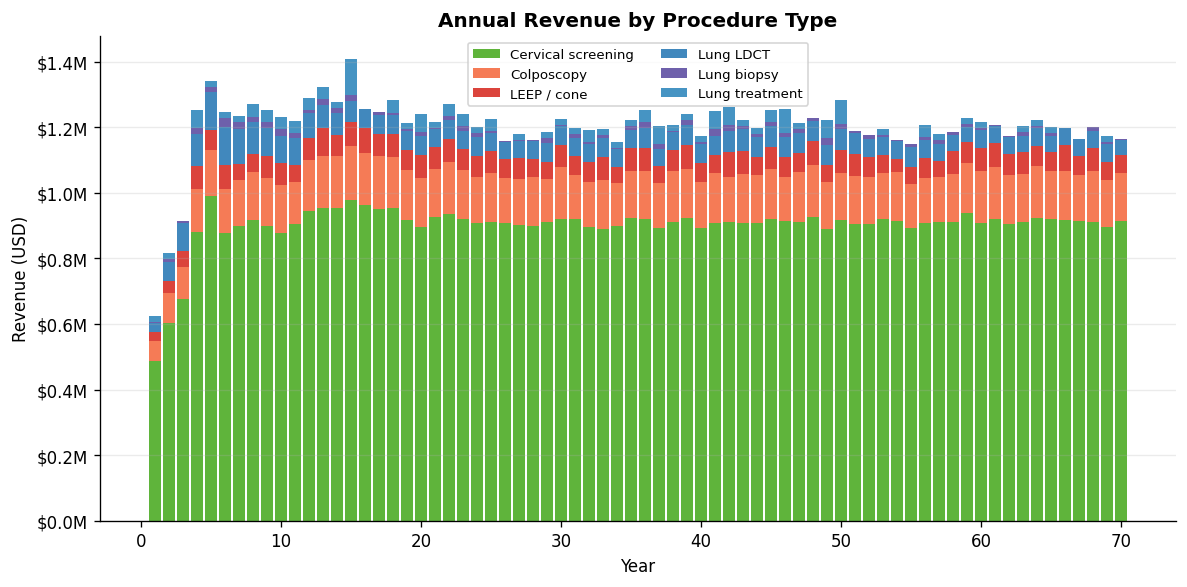

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = m.get("year_checkpoints", [])
years = [c["year"] for c in chk]

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

def rolling_avg(series, w=5):
    out = []
    for i in range(len(series)):
        window = series[max(0, i-w+1):i+1]
        out.append(sum(window) / len(window))
    return out

rev_cfg = cfg.PROCEDURE_REVENUE
ann_cerv  = ann("cum_cervical"); ann_colp = ann("cum_colposcopy"); ann_leep = ann("cum_leep")
ann_lung  = ann("cum_lung"); ann_lbx = ann("cum_lung_biopsy"); ann_ltx = ann("cum_lung_treatment")

ann_cerv_r = [c * (0.6*rev_cfg["cytology"] + 0.4*rev_cfg["hpv_alone"]) for c in ann_cerv]
ann_colp_r = [c * rev_cfg["colposcopy"] for c in ann_colp]
ann_leep_r = [c * rev_cfg["leep"] for c in ann_leep]
ann_lung_r = [c * rev_cfg["ldct"] for c in ann_lung]
ann_lbx_r  = [c * rev_cfg["lung_biopsy"] for c in ann_lbx]
ann_ltx_r  = [c * rev_cfg["lung_treatment"] for c in ann_ltx]

bar_series = {"Cervical screening": (ann_cerv_r, "#4dac26"), "Colposcopy": (ann_colp_r, "#f46d43"),
              "LEEP / cone": (ann_leep_r, "#d73027"), "Lung LDCT": (ann_lung_r, "#2c7bb6"),
              "Lung biopsy": (ann_lbx_r, "#5e4fa2"), "Lung treatment": (ann_ltx_r, "#3288bd")}

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
bottom = np.zeros(len(years))
for label, (vals, col) in bar_series.items():
    ax.bar(years, vals, bottom=bottom, color=col, label=label, width=0.85, alpha=0.9)
    bottom += np.array(vals)
ax.set_title("Annual Revenue by Procedure Type", fontsize=12, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Revenue (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend(fontsize=8, ncol=2); ax.grid(axis="y", alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "12_annual_revenue.png"), dpi=150, bbox_inches="tight")
plt.show()


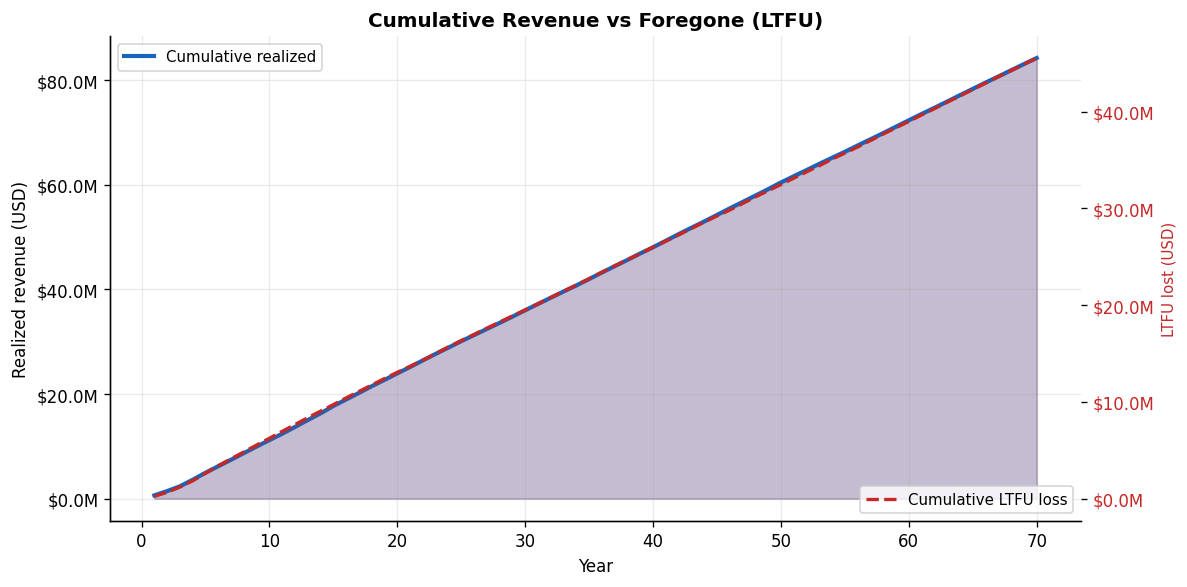

Total 70-yr realized revenue : $  84,248,903
Total LTFU lost revenue      : $  45,528,921
Revenue capture rate         : 64.9%


In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = m.get("year_checkpoints", [])
years = [c["year"] for c in chk]

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

def rolling_avg(series, w=5):
    out = []
    for i in range(len(series)):
        window = series[max(0, i-w+1):i+1]
        out.append(sum(window) / len(window))
    return out

rev_cfg = cfg.PROCEDURE_REVENUE
ann_cerv = ann("cum_cervical"); ann_colp = ann("cum_colposcopy"); ann_leep = ann("cum_leep")
ann_lung = ann("cum_lung"); ann_lbx = ann("cum_lung_biopsy"); ann_ltx = ann("cum_lung_treatment")
ann_ltfu = ann("cum_ltfu")

ann_cerv_r = [c * (0.6*rev_cfg["cytology"] + 0.4*rev_cfg["hpv_alone"]) for c in ann_cerv]
ann_colp_r = [c * rev_cfg["colposcopy"] for c in ann_colp]
ann_leep_r = [c * rev_cfg["leep"] for c in ann_leep]
ann_lung_r = [c * rev_cfg["ldct"] for c in ann_lung]
ann_lbx_r  = [c * rev_cfg["lung_biopsy"] for c in ann_lbx]
ann_ltx_r  = [c * rev_cfg["lung_treatment"] for c in ann_ltx]
ann_ltfu_r = [lt * (rev_cfg["colposcopy"] * 0.6 + rev_cfg["leep"] * 0.3) for lt in ann_ltfu]

ann_total_r = [sum(x) for x in zip(ann_cerv_r, ann_colp_r, ann_leep_r, ann_lung_r, ann_lbx_r, ann_ltx_r)]
cum_total_r = [sum(ann_total_r[:i+1]) for i in range(len(years))]
cum_ltfu_r  = [sum(ann_ltfu_r[:i+1]) for i in range(len(years))]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.fill_between(years, cum_total_r, alpha=0.25, color="#1565C0")
ax.plot(years, cum_total_r, color="#1565C0", lw=2.5, label="Cumulative realized")
ax2t = ax.twinx()
ax2t.fill_between(years, cum_ltfu_r, alpha=0.15, color="#C62828")
ax2t.plot(years, cum_ltfu_r, color="#C62828", lw=2, ls="--", label="Cumulative LTFU loss")
ax2t.set_ylabel("LTFU lost (USD)", fontsize=9, color="#C62828")
ax2t.tick_params(axis="y", labelcolor="#C62828")
ax2t.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.set_title("Cumulative Revenue vs Foregone (LTFU)", fontsize=12, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Realized revenue (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend(loc="upper left", fontsize=9); ax2t.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "13_cumulative_revenue.png"), dpi=150, bbox_inches="tight")
plt.show()

total_r = cum_total_r[-1]; total_lost = cum_ltfu_r[-1]
print(f"Total 70-yr realized revenue : ${total_r:>12,.0f}")
print(f"Total LTFU lost revenue      : ${total_lost:>12,.0f}")
print(f"Revenue capture rate         : {total_r/(total_r+total_lost)*100:.1f}%")


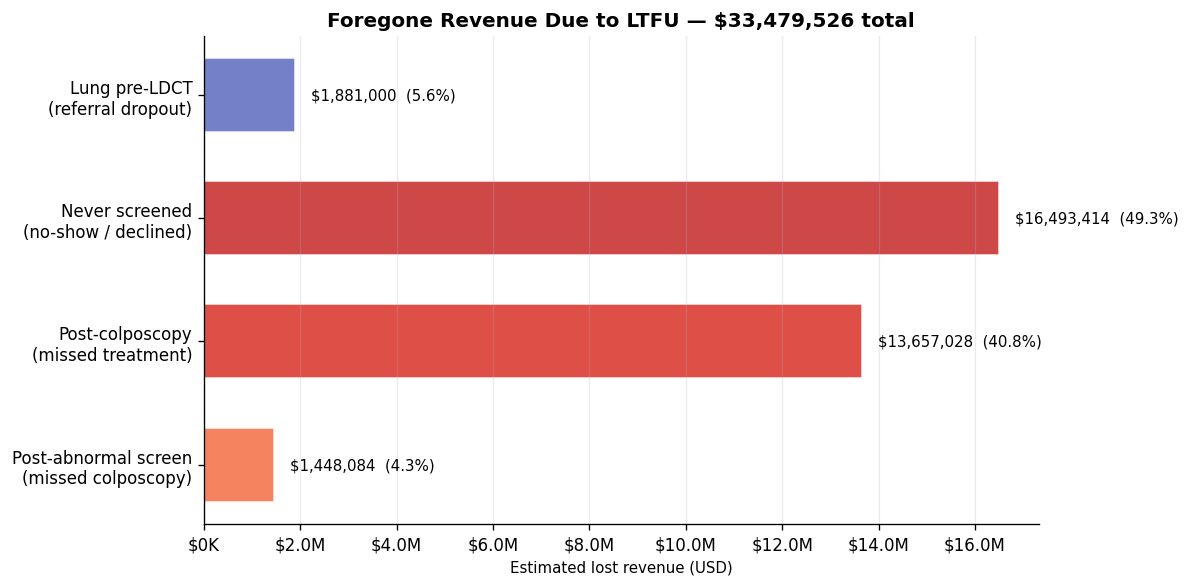


Foregone Revenue Breakdown (70 years):
  Post-abnormal screen (missed colposcopy)  $   1,448,084
  Post-colposcopy (missed treatment)        $  13,657,028
  Never screened (no-show / declined)       $  16,493,414
  Lung pre-LDCT (referral dropout)          $   1,881,000
  TOTAL                                     $  33,479,526


In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

# ── Foregone Revenue Due to LTFU ──────────────────────────────────────────────
# For each LTFU node, estimate the downstream procedures the patient would have
# received had they stayed in the system, and price them at PROCEDURE_REVENUE.

m   = metrics_70yr
rev = cfg.PROCEDURE_REVENUE

# LTFU buckets (cumulative totals across the full run)
ltfu_post_abnormal  = m.get("ltfu_post_abnormal", 0)    # had abnormal screen, never got colpo
ltfu_post_colpo     = m.get("ltfu_post_colposcopy", 0)  # had colpo, never got treatment
ltfu_unscreened     = m.get("ltfu_unscreened", 0)        # never screened (no-show / declined)
ltfu_noshow         = m.get("ltfu_noshow", 0)            # subset of unscreened from no-shows

# Lung LTFU (pre-LDCT dropoff)
lung_ref_placed     = m.get("lung_referral_placed", 0)
lung_ldct_done      = m.get("lung_ldct_completed", 0)
lung_ltfu_pre_ldct  = max(0, lung_ref_placed - lung_ldct_done)

# Foregone revenue per bucket
# Post-abnormal: would have had colposcopy + 30% chance of LEEP
foregone_post_abn   = ltfu_post_abnormal * (rev["colposcopy"] + 0.30 * rev["leep"])
# Post-colpo: would have had LEEP
foregone_post_colpo = ltfu_post_colpo * rev["leep"]
# Unscreened: would have had a screening test (weighted avg cervical)
avg_screen_rev      = 0.60 * rev["cytology"] + 0.40 * rev["hpv_alone"]
foregone_unscreened = ltfu_unscreened * avg_screen_rev
# Lung pre-LDCT: would have had LDCT
foregone_lung       = lung_ltfu_pre_ldct * rev["ldct"]

# Build chart data
buckets = [
    ("Post-abnormal screen\n(missed colposcopy)", foregone_post_abn, "#f46d43"),
    ("Post-colposcopy\n(missed treatment)",       foregone_post_colpo, "#d73027"),
    ("Never screened\n(no-show / declined)",       foregone_unscreened, "#C62828"),
    ("Lung pre-LDCT\n(referral dropout)",          foregone_lung, "#5C6BC0"),
]
labels  = [b[0] for b in buckets]
vals    = [b[1] for b in buckets]
colors  = [b[2] for b in buckets]
total   = sum(vals)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
bars = ax.barh(range(len(labels)), vals, color=colors, alpha=0.85, edgecolor="white", height=0.6)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)

for bar, val in zip(bars, vals):
    pct = 100 * val / max(total, 1)
    ax.text(bar.get_width() + total * 0.01, bar.get_y() + bar.get_height()/2,
            f"${val:,.0f}  ({pct:.1f}%)", va="center", fontsize=9)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x/1e3:.0f}K"))
ax.set_title(f"Foregone Revenue Due to LTFU — ${total:,.0f} total", fontsize=12, fontweight="bold")
ax.set_xlabel("Estimated lost revenue (USD)", fontsize=9)
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "14_foregone_revenue_ltfu.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nForegone Revenue Breakdown (70 years):")
for lbl, val in zip(labels, vals):
    print(f"  {lbl.replace(chr(10), ' '):40s}  ${val:>12,.0f}")
print(f"  {'TOTAL':40s}  ${total:>12,.0f}")

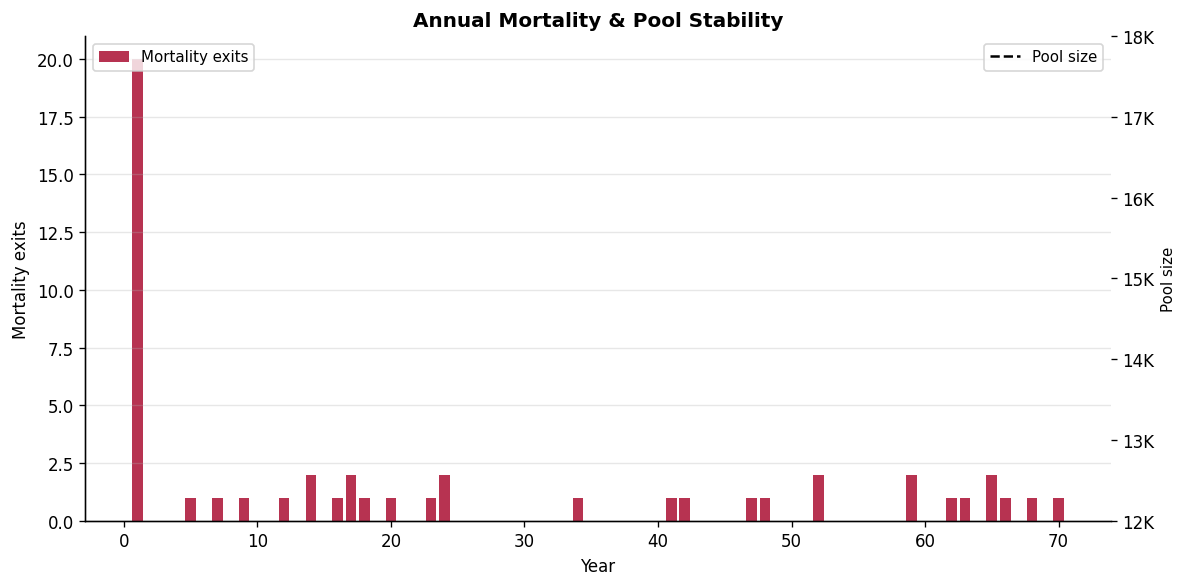

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = m.get("year_checkpoints", [])
years = [c["year"] for c in chk]

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

def rolling_avg(series, w=5):
    out = []
    for i in range(len(series)):
        window = series[max(0, i-w+1):i+1]
        out.append(sum(window) / len(window))
    return out

ann_mort  = ann("cum_mortality")
pool_size = [c["pool_size"] for c in chk]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.bar(years, ann_mort, color="#a50026", alpha=0.8, label="Mortality exits", width=0.8)
ax2t = ax.twinx()
ax2t.plot(years, pool_size, "k--", lw=1.5, label="Pool size")
ax2t.set_ylabel("Pool size", fontsize=9)
ax2t.set_ylim(cfg.SIMULATED_POPULATION * 0.8, cfg.SIMULATED_POPULATION * 1.2)
ax2t.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.set_title("Annual Mortality & Pool Stability", fontsize=12, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Mortality exits")
ax.legend(loc="upper left", fontsize=9); ax2t.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "15_mortality_pool.png"), dpi=150, bbox_inches="tight")
plt.show()


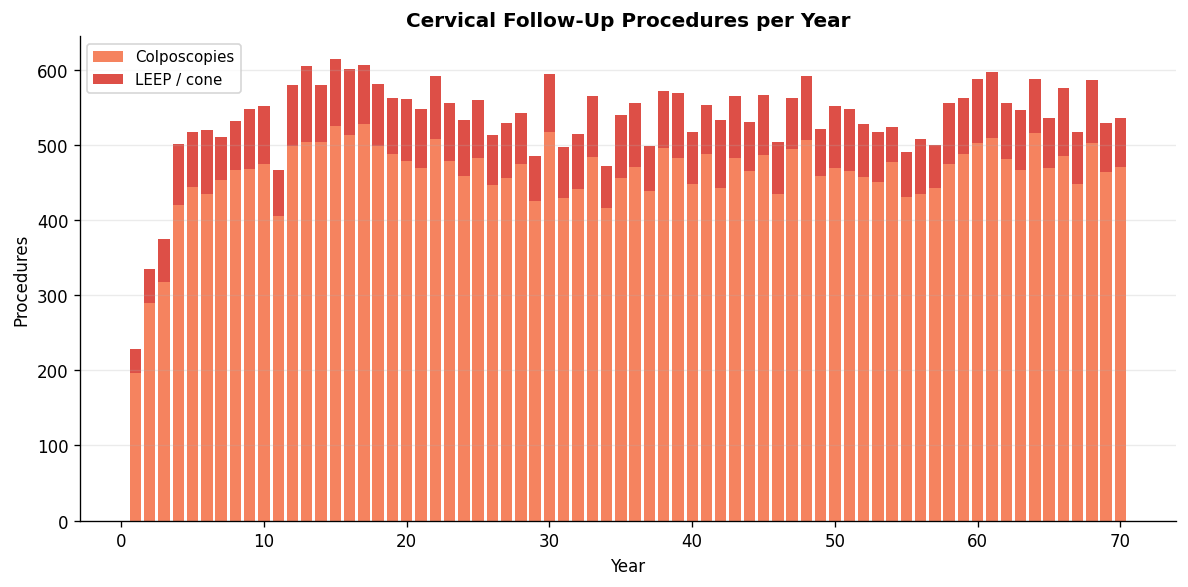

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = m.get("year_checkpoints", [])
years = [c["year"] for c in chk]

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

def rolling_avg(series, w=5):
    out = []
    for i in range(len(series)):
        window = series[max(0, i-w+1):i+1]
        out.append(sum(window) / len(window))
    return out

ann_colp = ann("cum_colposcopy")
ann_leep = ann("cum_leep")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.bar(years, ann_colp, color="#f46d43", alpha=0.85, label="Colposcopies", width=0.8)
ax.bar(years, ann_leep, color="#d73027", alpha=0.85, label="LEEP / cone", width=0.8, bottom=ann_colp)
ax.set_title("Cervical Follow-Up Procedures per Year", fontsize=12, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Procedures")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "16_cervical_followup.png"), dpi=150, bbox_inches="tight")
plt.show()


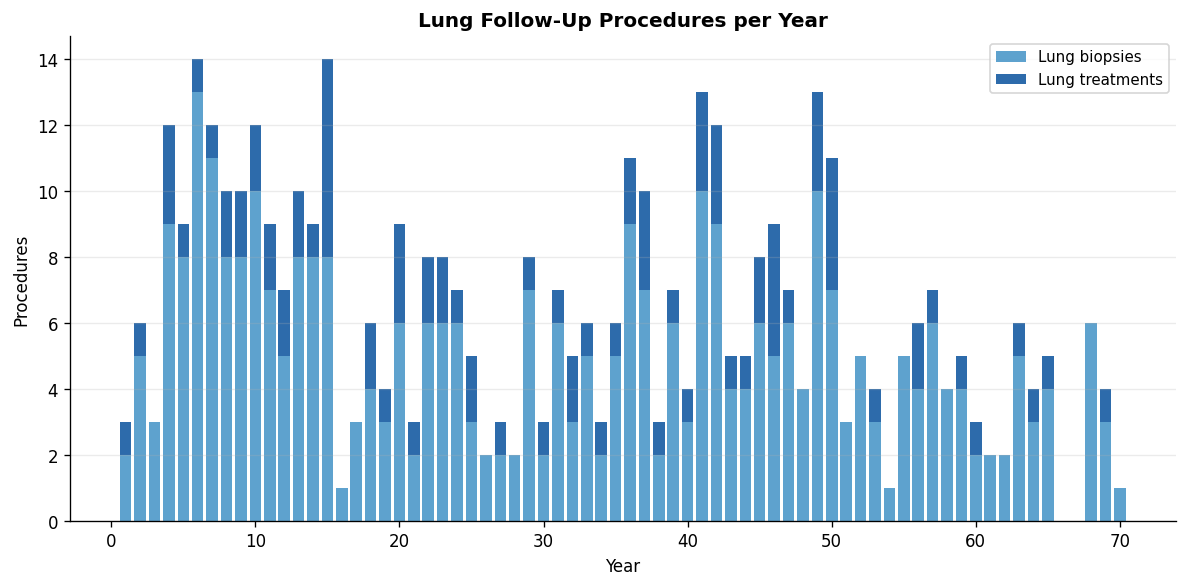

In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = m.get("year_checkpoints", [])
years = [c["year"] for c in chk]

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

def rolling_avg(series, w=5):
    out = []
    for i in range(len(series)):
        window = series[max(0, i-w+1):i+1]
        out.append(sum(window) / len(window))
    return out

ann_lbx = ann("cum_lung_biopsy")
ann_ltx = ann("cum_lung_treatment")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.bar(years, ann_lbx, color="#4292c6", alpha=0.85, label="Lung biopsies", width=0.8)
ax.bar(years, ann_ltx, color="#08519c", alpha=0.85, label="Lung treatments", width=0.8, bottom=ann_lbx)
ax.set_title("Lung Follow-Up Procedures per Year", fontsize=12, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Procedures")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "17_lung_followup.png"), dpi=150, bbox_inches="tight")
plt.show()


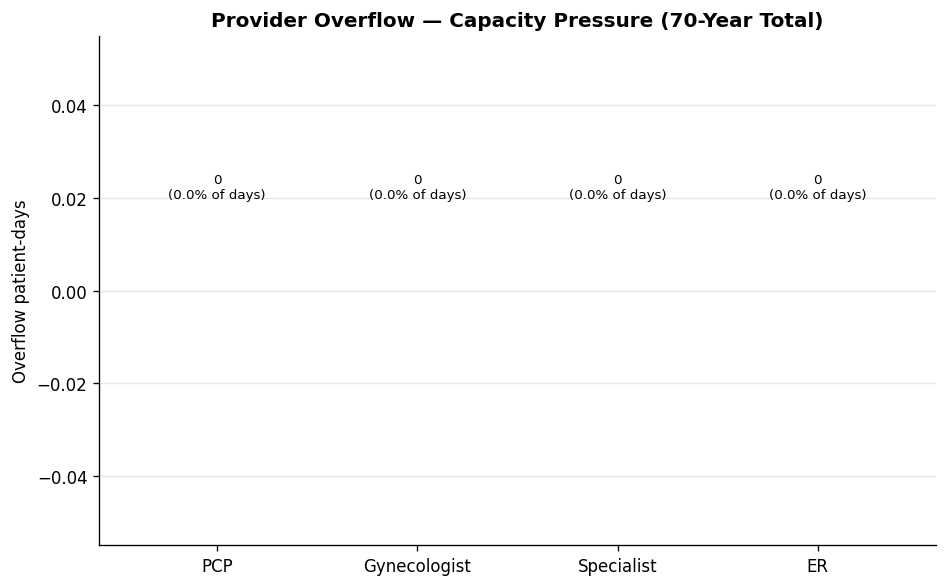

In [25]:
import matplotlib.pyplot as plt
import config as cfg

overflow  = metrics_70yr.get("overflow", {})
providers = ["pcp", "gynecologist", "specialist", "er"]
prov_lbls = ["PCP", "Gynecologist", "Specialist", "ER"]
ov_counts = [overflow.get(p, 0) for p in providers]
ov_colors = ["#2c7bb6", "#4dac26", "#fdae61", "#d73027"]
total_days = cfg.SIM_YEARS * 365

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("white")
bars = ax.bar(prov_lbls, ov_counts, color=ov_colors, edgecolor="white", alpha=0.85)
for bar, val in zip(bars, ov_counts):
    rate = val / total_days * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(ov_counts + [1]) * 0.02,
            f"{val:,}\n({rate:.1f}% of days)", ha="center", fontsize=8)
ax.set_title("Provider Overflow — Capacity Pressure (70-Year Total)", fontsize=12, fontweight="bold")
ax.set_ylabel("Overflow patient-days")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "18_provider_overflow.png"), dpi=150, bbox_inches="tight")
plt.show()


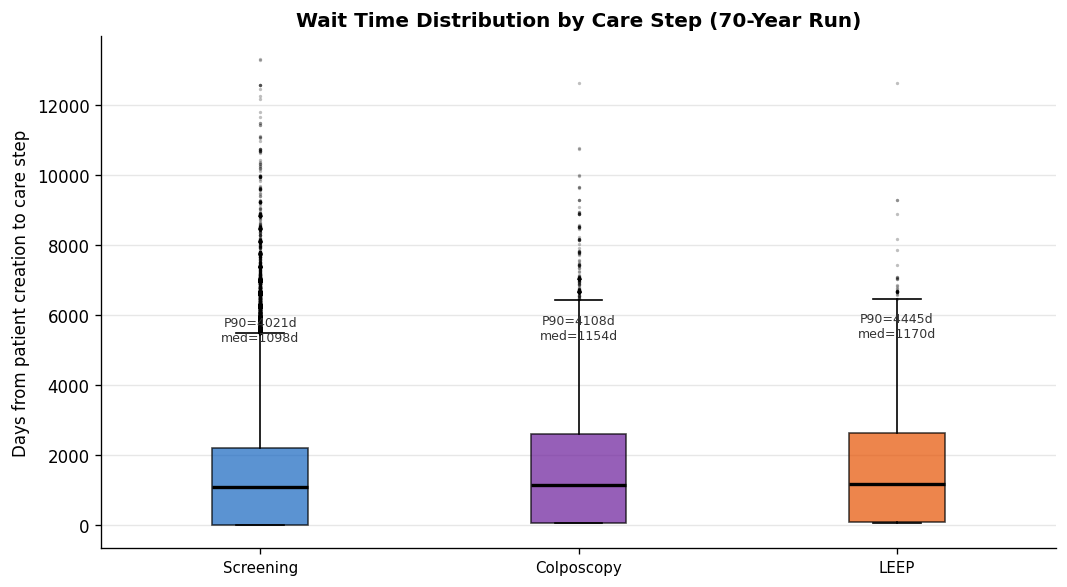

Step                        N     Mean    Med    P90
Screening             380,300   1406.8 1098.0 4021.0
Colposcopy             32,342   1618.0 1154.0 4108.0
LEEP                    5,131   1658.9 1170.0 4445.0


In [26]:
import matplotlib.pyplot as plt
import numpy as np

wt = metrics_70yr.get("wait_times", {})
resources_ordered = ["screening_seen", "colposcopy", "leep", "lung_biopsy"]
resource_labels   = {"screening_seen": "Screening", "colposcopy": "Colposcopy",
                     "leep": "LEEP", "lung_biopsy": "Lung Biopsy"}
res_colors = ["#1565C0", "#6A1B9A", "#E65100", "#C62828"]

present = [(r, resource_labels[r], c) for r, c in zip(resources_ordered, res_colors)
           if r in wt and len(wt[r]) > 0]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")
if present:
    box_data = [wt[r] for r, _, _ in present]
    box_lbls = [lbl for _, lbl, _ in present]
    bp = ax.boxplot(box_data, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.25))
    for patch, (_, _, col) in zip(bp["boxes"], present):
        patch.set_facecolor(col); patch.set_alpha(0.70)
    ax.set_xticklabels(box_lbls, fontsize=9)
    ax.set_ylabel("Days from patient creation to care step")
    for i, (res, _, _) in enumerate(present, 1):
        d = wt[res]
        ax.text(i, np.percentile(d, 97) * 1.03,
                f"P90={np.percentile(d, 90):.0f}d\nmed={np.median(d):.0f}d",
                ha="center", fontsize=7.5, color="#333")
ax.set_title("Wait Time Distribution by Care Step (70-Year Run)", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "19_wait_times.png"), dpi=150, bbox_inches="tight")
plt.show()

if present:
    print(f"{'Step':<18} {'N':>10} {'Mean':>8} {'Med':>6} {'P90':>6}")
    for res, lbl, _ in present:
        d = wt[res]
        print(f"{lbl:<18} {len(d):>10,} {np.mean(d):>8.1f} {np.median(d):>6.1f} {np.percentile(d,90):>6.1f}")


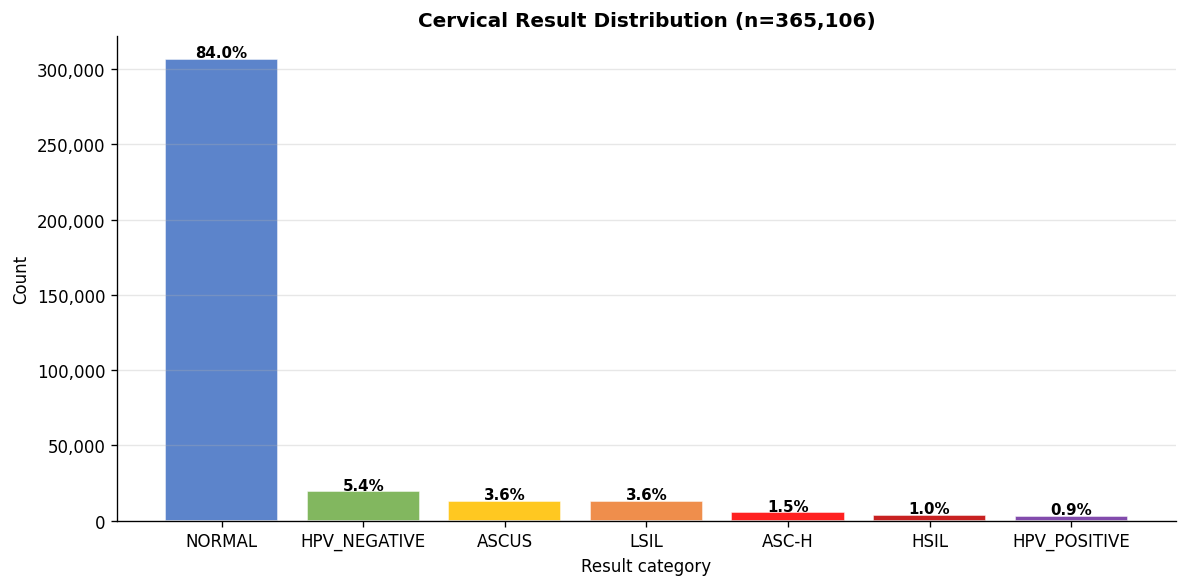

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

CERV_ORDER  = ["NORMAL", "HPV_NEGATIVE", "ASCUS", "LSIL", "ASC-H", "HSIL", "HPV_POSITIVE"]
CERV_COLORS = ["#4472C4", "#70AD47", "#FFC000", "#ED7D31", "#FF0000", "#C00000", "#7030A0"]

cerv_res   = metrics_70yr.get("cervical_results", {})
total_cerv = sum(cerv_res.values()) or 1
labels_cerv = [r for r in CERV_ORDER if cerv_res.get(r, 0) > 0]
counts_cerv = [cerv_res[r] for r in labels_cerv]
pcts_cerv   = [100 * c / total_cerv for c in counts_cerv]
colors_cerv = [CERV_COLORS[CERV_ORDER.index(r)] for r in labels_cerv]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
bars = ax.bar(labels_cerv, counts_cerv, color=colors_cerv, alpha=0.87, edgecolor="white")
for bar, pct in zip(bars, pcts_cerv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_cerv * 0.003,
            f"{pct:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_title(f"Cervical Result Distribution (n={total_cerv:,})", fontsize=12, fontweight="bold")
ax.set_ylabel("Count"); ax.set_xlabel("Result category")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="y", alpha=0.3); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "20_cervical_results.png"), dpi=150, bbox_inches="tight")
plt.show()


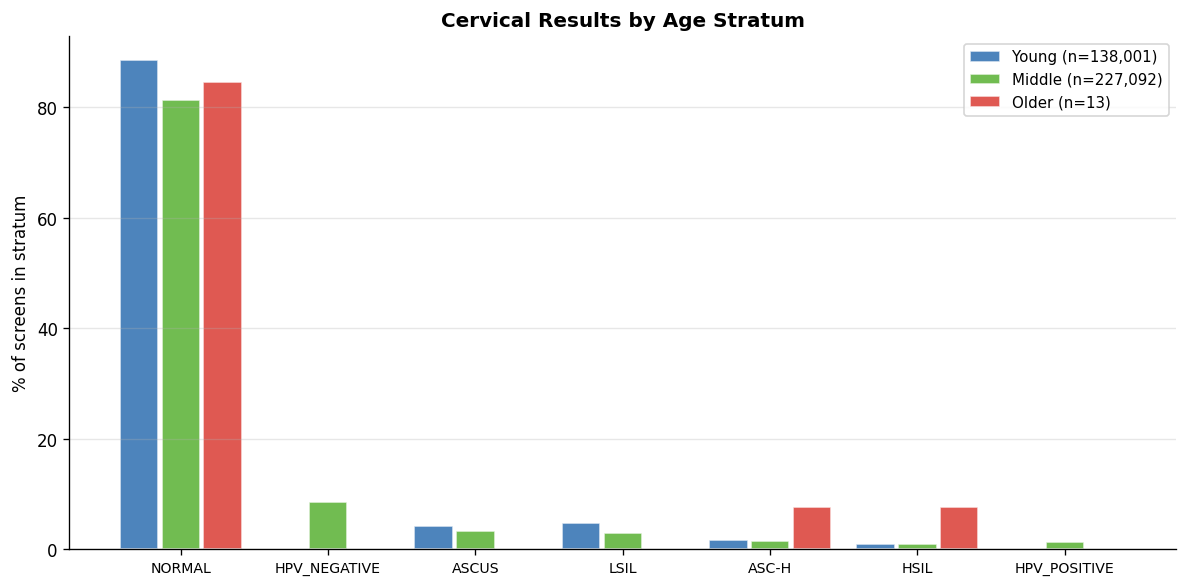

In [28]:
import matplotlib.pyplot as plt
import numpy as np

CERV_ORDER = ["NORMAL", "HPV_NEGATIVE", "ASCUS", "LSIL", "ASC-H", "HSIL", "HPV_POSITIVE"]
strat_data = metrics_70yr.get("cervical_by_age_stratum", {})
strata     = [s for s in ("young", "middle", "older") if strat_data.get(s)]
common_res = [r for r in CERV_ORDER if any(strat_data[s].get(r, 0) for s in strata)]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
if strata and common_res:
    x     = np.arange(len(common_res))
    width = 0.85 / len(strata)
    pal   = ["#2166AC", "#4DAC26", "#D73027"]
    for j, (st, col) in enumerate(zip(strata, pal)):
        total_st = sum(strat_data[st].values()) or 1
        pcts_st  = [100 * strat_data[st].get(r, 0) / total_st for r in common_res]
        ax.bar(x + j * width, pcts_st, width=width * 0.92,
               label=f"{st.title()} (n={total_st:,})", color=col, alpha=0.80, edgecolor="white")
    ax.set_xticks(x + width * (len(strata) - 1) / 2)
    ax.set_xticklabels(common_res, fontsize=8.5)
    ax.set_ylabel("% of screens in stratum")
    ax.legend(fontsize=9)
ax.set_title("Cervical Results by Age Stratum", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "21_cervical_by_age.png"), dpi=150, bbox_inches="tight")
plt.show()


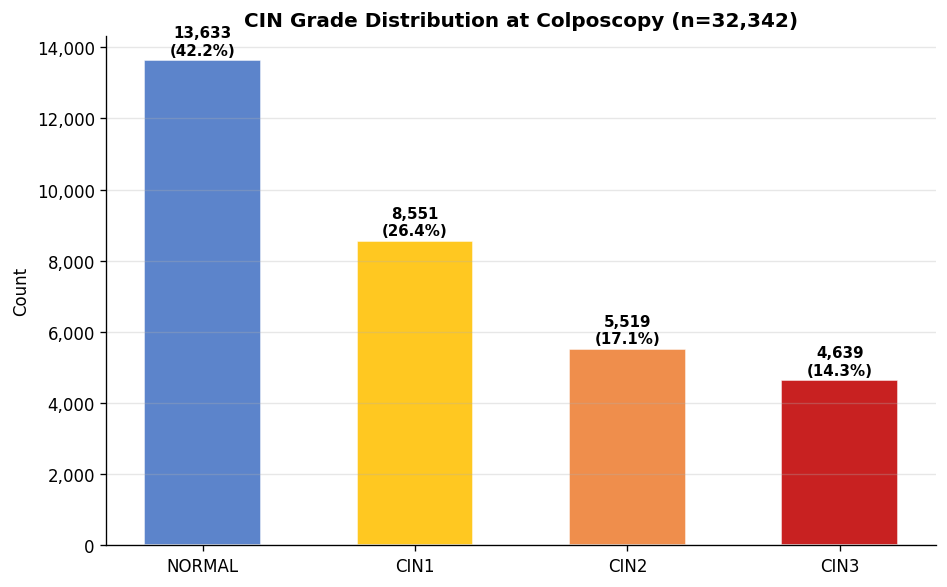

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

CIN_ORDER  = ["NORMAL", "CIN1", "CIN2", "CIN3"]
CIN_COLORS = ["#4472C4", "#FFC000", "#ED7D31", "#C00000"]

colpo_res   = metrics_70yr.get("colposcopy_results", {})
total_colpo = sum(colpo_res.values()) or 1
labels_cin  = [c for c in CIN_ORDER if colpo_res.get(c, 0) > 0]
counts_cin  = [colpo_res[c] for c in labels_cin]
pcts_cin    = [100 * c / total_colpo for c in counts_cin]
colors_cin  = [CIN_COLORS[CIN_ORDER.index(c)] for c in labels_cin]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("white")
if labels_cin:
    bars = ax.bar(labels_cin, counts_cin, color=colors_cin, alpha=0.87, edgecolor="white", width=0.55)
    for bar, val, pct in zip(bars, counts_cin, pcts_cin):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_colpo * 0.005,
                f"{val:,}\n({pct:.1f}%)", ha="center", fontsize=9, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_title(f"CIN Grade Distribution at Colposcopy (n={total_colpo:,})", fontsize=12, fontweight="bold")
ax.set_ylabel("Count"); ax.grid(axis="y", alpha=0.3); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "22_cin_grades.png"), dpi=150, bbox_inches="tight")
plt.show()


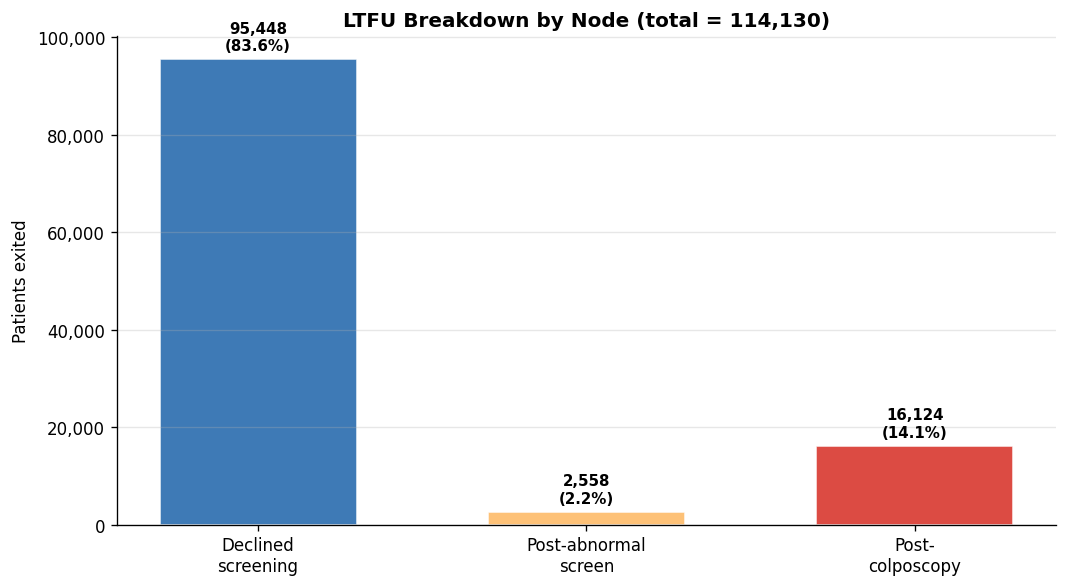

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

m = metrics_70yr
ltfu_nodes = [
    ("Declined\nscreening",   m.get("ltfu_unscreened", 0),      "#2166AC"),
    ("No-show\ncascade",      m.get("ltfu_noshow", 0),           "#4DAC26"),
    ("Post-abnormal\nscreen", m.get("ltfu_post_abnormal", 0),    "#FDB863"),
    ("Post-\ncolposcopy",     m.get("ltfu_post_colposcopy", 0),  "#D73027"),
    ("Overdue pool\ntimeout", m.get("n_overdue_exit", 0),        "#762A83"),
]
total_ltfu = sum(v for _, v, _ in ltfu_nodes)
lbls  = [l for l, v, _ in ltfu_nodes if v > 0]
vals  = [v for _, v, _ in ltfu_nodes if v > 0]
cols  = [c for _, v, c in ltfu_nodes if v > 0]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")
if vals:
    bars = ax.bar(lbls, vals, color=cols, alpha=0.87, edgecolor="white", width=0.6)
    for bar, val in zip(bars, vals):
        pct = 100 * val / max(total_ltfu, 1)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals) * 0.02,
                f"{val:,}\n({pct:.1f}%)", ha="center", fontsize=9, fontweight="bold")
ax.set_title(f"LTFU Breakdown by Node (total = {total_ltfu:,})", fontsize=12, fontweight="bold")
ax.set_ylabel("Patients exited")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="y", alpha=0.3); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "23_ltfu_breakdown.png"), dpi=150, bbox_inches="tight")
plt.show()


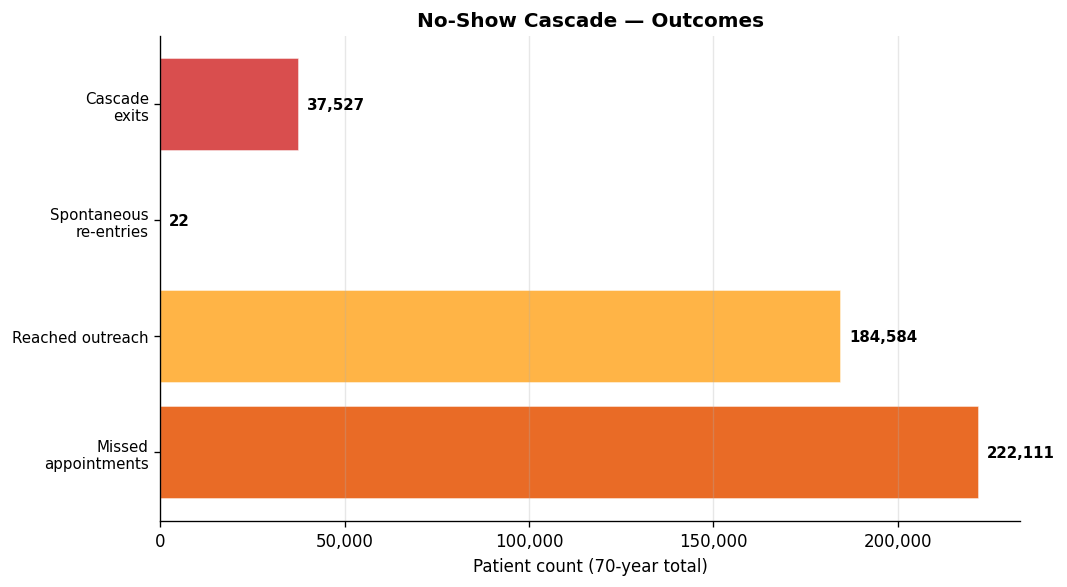

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

m = metrics_70yr
n_ns  = m.get("n_noshow", 0)
n_nsx = m.get("n_noshow_exit", 0)
n_sr  = m.get("n_spontaneous_reentry", 0)
n_ov  = m.get("n_overdue_exit", 0)
n_rescued = n_ns - n_nsx

cascade_steps = [
    ("Missed\nappointments",     n_ns,      "#E65100"),
    ("Reached outreach",         n_rescued,  "#FFA726"),
    ("Spontaneous\nre-entries", n_sr,       "#66BB6A"),
    ("Cascade\nexits",          n_nsx,      "#D32F2F"),
    ("Overdue pool\ntimeouts",  n_ov,       "#7B1FA2"),
]
labels_c = [l for l, v, _ in cascade_steps if v > 0]
vals_c   = [v for _, v, _ in cascade_steps if v > 0]
cols_c   = [c for _, v, c in cascade_steps if v > 0]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")
if vals_c:
    bars = ax.barh(range(len(labels_c)), vals_c, color=cols_c, alpha=0.85, edgecolor="white")
    ax.set_yticks(range(len(labels_c)))
    ax.set_yticklabels(labels_c, fontsize=9)
    for bar, val in zip(bars, vals_c):
        ax.text(bar.get_width() + max(vals_c) * 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:,}", va="center", fontsize=9, fontweight="bold")
    ax.set_xlabel("Patient count (70-year total)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_title("No-Show Cascade — Outcomes", fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "24_noshow_cascade.png"), dpi=150, bbox_inches="tight")
plt.show()


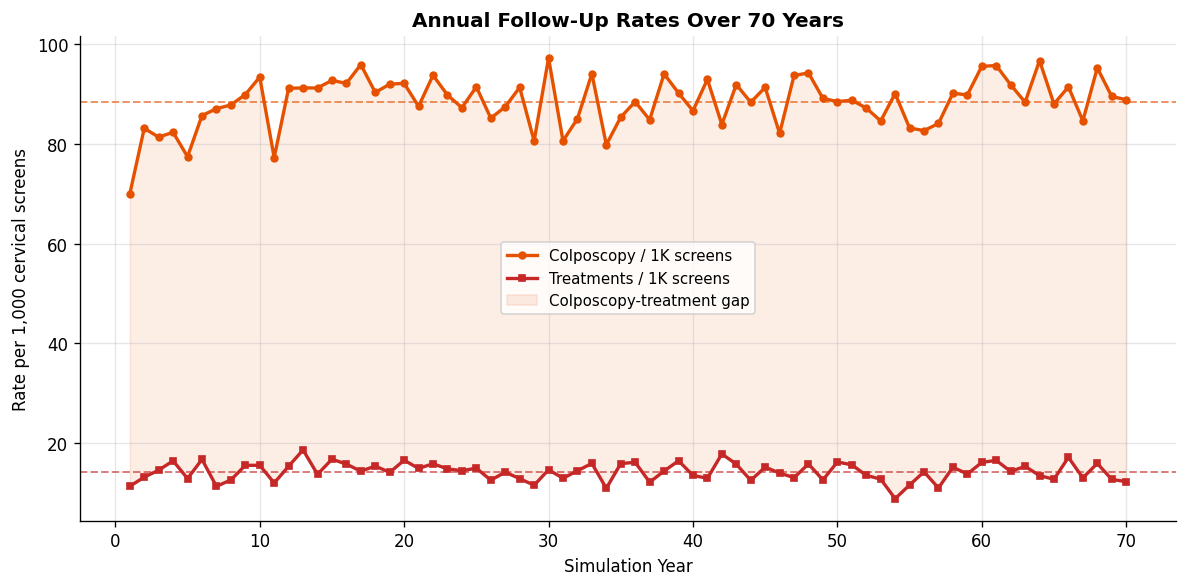

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = m.get("year_checkpoints", [])
years = [c["year"] for c in chk]

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

def rolling_avg(series, w=5):
    out = []
    for i in range(len(series)):
        window = series[max(0, i-w+1):i+1]
        out.append(sum(window) / len(window))
    return out

ann_cerv    = ann("cum_cervical")
ann_colpo   = ann("cum_colposcopy")
ann_treated_list = ann("cum_treated")

colpo_rate   = [1000 * co / max(ce, 1) for co, ce in zip(ann_colpo, ann_cerv)]
treated_rate = [1000 * tr / max(ce, 1) for tr, ce in zip(ann_treated_list, ann_cerv)]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.plot(years, colpo_rate, color="#E65100", lw=2, marker="o", ms=4, label="Colposcopy / 1K screens")
ax.plot(years, treated_rate, color="#C62828", lw=2, marker="s", ms=4, label="Treatments / 1K screens")
ax.fill_between(years, treated_rate, colpo_rate, alpha=0.10, color="#E65100",
                label="Colposcopy-treatment gap")
ax.axhline(np.mean(colpo_rate), color="#E65100", lw=1.2, ls="--", alpha=0.6)
ax.axhline(np.mean(treated_rate), color="#C62828", lw=1.2, ls="--", alpha=0.6)
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Rate per 1,000 cervical screens")
ax.set_title("Annual Follow-Up Rates Over 70 Years", fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "25_followup_rates.png"), dpi=150, bbox_inches="tight")
plt.show()


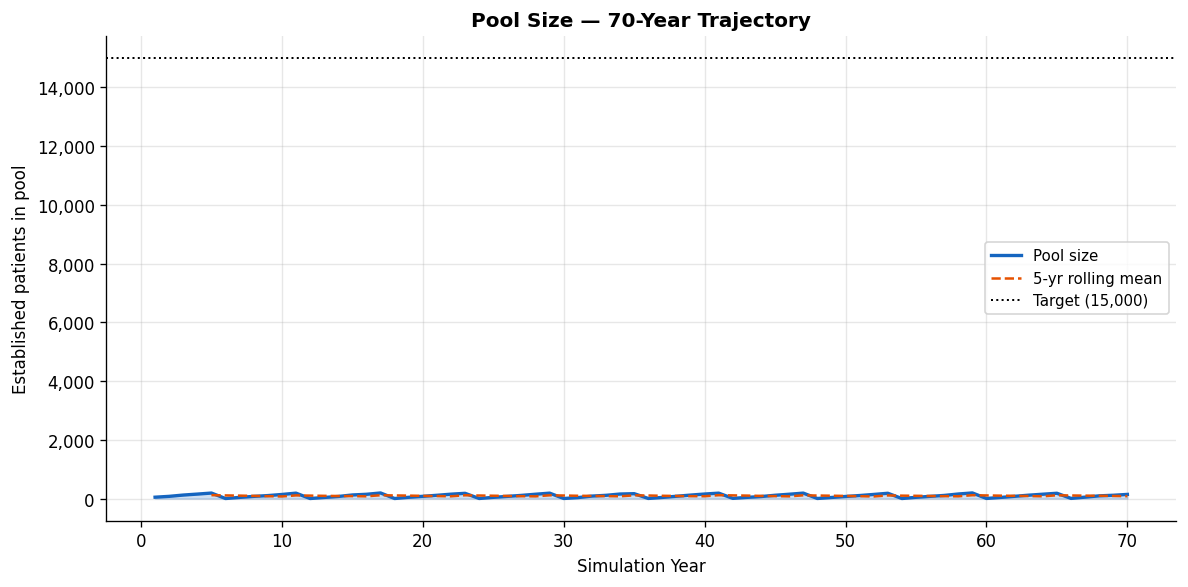

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = m.get("year_checkpoints", [])
years = [c["year"] for c in chk]

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

def rolling_avg(series, w=5):
    out = []
    for i in range(len(series)):
        window = series[max(0, i-w+1):i+1]
        out.append(sum(window) / len(window))
    return out

pool_size = np.array([c["pool_size"] for c in chk])
yrs       = np.array(years)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.fill_between(yrs, pool_size, alpha=0.20, color="#1565C0")
ax.plot(yrs, pool_size, color="#1565C0", lw=2, label="Pool size")
if len(pool_size) >= 5:
    roll5 = np.convolve(pool_size, np.ones(5)/5, mode="valid")
    ax.plot(yrs[4:], roll5, color="#E65100", lw=1.5, ls="--", label="5-yr rolling mean")
ax.axhline(cfg.SIMULATED_POPULATION, color="black", lw=1.2, ls=":",
           label=f"Target ({cfg.SIMULATED_POPULATION:,})")
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Established patients in pool")
ax.set_title("Pool Size — 70-Year Trajectory", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "26_pool_size.png"), dpi=150, bbox_inches="tight")
plt.show()


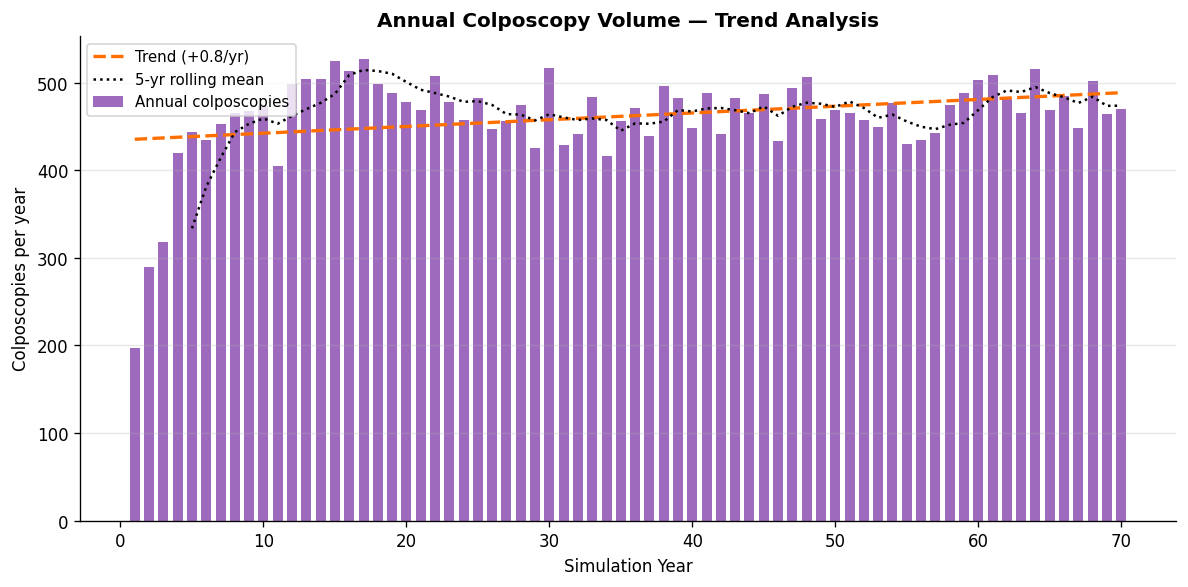

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import config as cfg

m   = metrics_70yr
chk = m.get("year_checkpoints", [])
years = [c["year"] for c in chk]

def ann(key):
    vals = [c.get(key, 0) for c in chk]
    return [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]

def rolling_avg(series, w=5):
    out = []
    for i in range(len(series)):
        window = series[max(0, i-w+1):i+1]
        out.append(sum(window) / len(window))
    return out

ann_colpo = np.array(ann("cum_colposcopy"))
yrs       = np.array(years)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.bar(yrs, ann_colpo, color="#6A1B9A", alpha=0.65, width=0.7, label="Annual colposcopies")
if len(yrs) > 2:
    z = np.polyfit(yrs, ann_colpo, 1)
    p = np.poly1d(z)
    ax.plot(yrs, p(yrs), color="#FF6F00", lw=2, ls="--", label=f"Trend ({z[0]:+.1f}/yr)")
if len(ann_colpo) >= 5:
    roll5c = np.convolve(ann_colpo, np.ones(5)/5, mode="valid")
    ax.plot(yrs[4:], roll5c, color="black", lw=1.5, ls=":", label="5-yr rolling mean")
ax.set_xlabel("Simulation Year"); ax.set_ylabel("Colposcopies per year")
ax.set_title("Annual Colposcopy Volume — Trend Analysis", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "27_colposcopy_trend.png"), dpi=150, bbox_inches="tight")
plt.show()


---

## 1-Year Simulation

A single-year snapshot — useful for quickly checking how a parameter change affects screening throughput and outcomes before committing to a full 70-year run.

In [35]:

# ── Standalone run via SimulationRunner ───────────────────────────────────────
# This cell uses runner.py directly — no dependency on Sophia's SimPy notebook.
# SimulationRunner handles arrivals, queues, screening, and follow-up in one
# clean class. Switch use_stable_population=True for the 70-year cycling model.

import sys
sys.path.insert(0, '../src')

from runner import SimulationRunner
import config as cfg

print("Running 1-year simulation (SimulationRunner, standard mode)...")
sim = SimulationRunner(
    n_days     = 365,
    seed       = cfg.RANDOM_SEED,
    daily_rate = cfg.DAILY_PATIENTS,
    use_stable_population = False,   # standard mode: Poisson arrivals, no cycling
)
metrics = sim.run()

print(f"Done. Provider visits logged : {metrics['n_patients']:,}")
print(f"Eligible for any screening  : {metrics['n_eligible_any']:,}")
print(f"Cervical screened           : {metrics['n_screened']['cervical']:,}")
print(f"Lung screened               : {metrics['n_screened']['lung']:,}")
print()
sim.summary()


Running 1-year simulation (SimulationRunner, standard mode)...
Done. Provider visits logged : 24,206
Eligible for any screening  : 16,418
Cervical screened           : 15,543
Lung screened               : 540

NYP WOMEN'S HEALTH SCREENING SIMULATION — RESULTS

Patients simulated:                        24,206
Eligible for ≥1 screening:                 16,418
Unscreened (declined / no-show):            7,788  (32.2%)
  ↳ agreed to reschedule:                       0  (0.0% of unscreened)

Screenings completed by cancer type:
  cervical                 15,543
  lung                        540

Cervical result distribution  (n=15,543):
  ASC-H                             208  (1.3%)
  ASCUS                             567  (3.6%)
  HPV_NEGATIVE                    1,041  (6.7%)
  HPV_POSITIVE                      181  (1.2%)
  HSIL                              150  (1.0%)
  LSIL                              498  (3.2%)
  NORMAL                         12,898  (83.0%)
  Abnormal rate:      

---

## Step-by-Step Breakdown

Technical walkthrough of the daily simulation engine. Shows how the arrivals layer, screening logic, queue processor, and event loop connect. Intended for development and debugging — the full model runs from `SimulationRunner` without any of the code below.

## Load Sophia's Arrival Functions

`%run` executes Sophia's notebook in its entirety and imports all of her functions and global variables into this notebook's namespace. This is equivalent to copy-pasting her code here, but means we always use her latest version without duplication.

After `%run`, we override only the patient-generation step (`generate_daily_arrivals`) to use our enriched `Patient` class — everything else (queue management, scheduling, ER routing) is hers unchanged.

**Namespace note**: `%run` will also load Sophia's `print_summary` function, which prints her arrivals summary. We import our own `print_summary` as `print_screening_summary` before this cell runs, so both can coexist.

In [36]:
%run "../archive/initial_model_NYP_flow_simulation (1).ipynb"

# Confirm Sophia's key functions are loaded
print('Sophia functions loaded:', [f for f in dir() if f in (
    'initialize_state', 'generate_daily_arrivals', 'process_provider_queue',
    'process_er_queue', 'release_scheduled_patients_for_today',
    'release_returning_er_patients', 'is_weekday', 'next_weekday',
)])

zsh:1: command not found: pip


ModuleNotFoundError: No module named 'simpy'

ModuleNotFoundError: No module named 'simpy'

## Extended Patient Generation

Sophia's `generate_daily_arrivals` creates a plain `Patient` with only the fields her queue model needs (id, type, destination). We replace it with `generate_enriched_daily_arrivals` which calls `population.sample_patient` instead.

`sample_patient` draws the full clinical profile for each patient — age, race, insurance, HPV status, smoking history, BMI, prior CIN, etc. — from NYC-calibrated demographic distributions. These fields are what the screening eligibility checks and result-draw functions read when they evaluate the patient downstream.

This is the only change we make to the arrivals layer. Once a patient is created, Sophia's queue routing functions handle them the same way they would handle a plain `Patient` object.

In [ ]:
def generate_enriched_daily_arrivals(day: int, state: dict, next_patient_id: int) -> int:
    """
    Generate DAILY_PATIENTS enriched patients for one weekday.

    Replaces Sophia's generate_daily_arrivals with population.sample_patient so
    each patient carries demographics and clinical flags from the population model.
    Queue routing logic (drop-in vs. outpatient, ER vs. PCP/GYN) mirrors Sophia's original.

    Returns the updated next_patient_id counter.
    """
    for _ in range(cfg.DAILY_PATIENTS):
        # Draw type and destination using config probability tables
        patient_type = random.choices(
            list(cfg.PATIENT_TYPE_PROBS.keys()),
            weights=list(cfg.PATIENT_TYPE_PROBS.values())
        )[0]
        destination = random.choices(
            list(cfg.DESTINATION_PROBS.keys()),
            weights=list(cfg.DESTINATION_PROBS.values())
        )[0]

        # sample_patient creates a Patient with age, race, clinical flags, etc.
        # from the population distribution — this is the enrichment over Sophia's version
        patient = sample_patient(next_patient_id, day, destination, patient_type)
        next_patient_id += 1

        # ER patients get a critical flag — critical patients return the next day
        # for follow-up instead of being routed to an outpatient queue
        if destination == 'er':
            patient.critical_status = random.random() < cfg.ER_CRITICAL_PROB

        # Append to global patient list and increment arrival counters
        state['all_patients'].append(patient)
        state['patients_created'] += 1
        state['created_by_type'][patient_type] += 1
        state['created_by_destination'][destination] += 1

        # Route into today's queue: outpatients go through scheduling,
        # ER drop-ins go directly to the ER queue
        if patient_type == 'outpatient':
            add_patient_to_today_queue(patient, state)
        elif destination == 'er':
            state['er_today'].append(patient)
        else:
            add_patient_to_today_queue(patient, state)

    return next_patient_id

print('generate_enriched_daily_arrivals defined')

## Post-Provider Screening Step

This is the **integration point** between Sophia's layer and ours. Every time a patient is seen by a provider (PCP, GYN, or Specialist), we immediately run Steps 2–5:

1. **Eligibility** — `get_eligible_screenings` checks age, cervix status, and smoking history against USPSTF criteria for each active cancer type.
2. **Screening** — `run_screening_step` assigns the test modality and draws a stochastic result. For lung, it also runs the pre-LDCT referral + scheduling pathway.
3. **Follow-up** — `run_cervical_followup` or `run_lung_followup` routes the result through the clinical decision tree (colposcopy, biopsy, treatment).

Patients who are ineligible for all active cancers are counted and skipped. Patients who exit the system mid-encounter (e.g. lost to follow-up during lung pre-LDCT) are not processed for additional cancers.

In [ ]:
def run_post_provider_screening(patient: Patient, day: int, metrics: dict) -> None:
    """
    Execute screening steps for one patient who has just been seen by a provider.
    Updates the patient object in place and writes results to metrics.

    Flow:
      1. Get the list of cancer types this patient is eligible for right now.
      2. If none → patient is not eligible for any active screening today; just count and return.
      3. For each eligible cancer → run_screening_step (lung pre-LDCT pathway runs inside).
      4. For each non-None result → route to cancer-specific follow-up function.
    """
    metrics['n_patients'] += 1

    # get_eligible_screenings filters by ACTIVE_CANCERS and applies all eligibility rules
    eligible = get_eligible_screenings(patient)

    if not eligible:
        # Patient doesn't meet criteria for any active cancer screening today
        # (wrong age, no cervix, not enough pack-years, etc.) — nothing to do
        metrics['n_unscreened'] += 1
        return

    metrics['n_eligible_any'] += 1

    for cancer in eligible:
        # If the patient exited mid-encounter (e.g. lost to follow-up in lung pre-LDCT),
        # stop processing further cancers for this visit
        if not patient.active:
            break

        # run_screening_step checks interval, assigns test, draws result, writes to patient.
        # Returns None if skipped (not yet due) or patient was lost before scan.
        # Passes metrics so lung funnel counters (referral, scheduled, completed) are populated.
        result = run_screening_step(patient, cancer, day, metrics=metrics)
        if result is None:
            continue  # not due yet, or lost before scan — no follow-up needed

        # Write the (cancer, result) pair to the metrics screening table
        record_screening(metrics, patient, cancer, result)

        # Route to the cancer-specific follow-up chain.
        # cervical: route_cervical_result → run_colposcopy → run_treatment
        # lung:     communicate → biopsy referral → biopsy → treatment
        # Other cancers are excluded by ACTIVE_CANCERS in get_eligible_screenings.
        if cancer == 'cervical':
            run_cervical_followup(patient, day, metrics)
        elif cancer == 'lung':
            run_lung_followup(patient, day, metrics)

        # If the follow-up chain marked the patient as exited, record that exit reason
        if patient.exit_reason:
            record_exit(metrics, patient.exit_reason)

print('run_post_provider_screening defined')

## Extended Provider Queue Processor

Sophia's `process_provider_queue` drains the daily queue for one provider type, marks patients as seen up to the day's capacity, and reschedules the overflow. We wrap it here to inject the screening step for every seen patient.

The ER is handled separately by Sophia's `process_er_queue` — we do not screen in the ER in the current model (no cancer screening is appropriate in an emergency setting).

In [ ]:
def process_provider_queue_with_screening(
    day: int, queue: deque, capacity: int,
    provider_name: str, state: dict, metrics: dict
) -> None:
    """
    Sophia's provider queue logic plus a screening step for every seen patient.

    Patients up to `capacity` are marked seen; the rest are rescheduled.
    For each seen patient, run_post_provider_screening immediately triggers
    Steps 2–5 (eligibility → test → result → follow-up).
    """
    seen = 0

    while queue:
        patient = queue.popleft()

        if seen < capacity:
            # Patient is seen today — increment counter and log the visit
            seen += 1
            state['seen_by_destination'][provider_name] += 1
            log_day(state, day, f'Patient {patient.patient_id} seen by {provider_name}')

            # ── Steps 2–5: screening + follow-up ────────────────────────────
            # Runs immediately after the provider visit, same day
            run_post_provider_screening(patient, day, metrics)

        else:
            # Provider is at capacity — patient must wait and come back
            patient.wait_days += 1
            state['not_seen_by_destination'][provider_name] += 1

            # Drop-ins are converted to outpatient appointments for the next weekday;
            # already-scheduled outpatients are simply pushed to the next weekday slot
            if patient.patient_type == 'drop_in':
                patient.patient_type  = 'outpatient'
                patient.scheduled_day = next_weekday(day)
                state['future_schedule'][patient.scheduled_day].append(patient)
                state['converted_dropin_to_outpatient'] += 1
            else:
                patient.scheduled_day = next_weekday(day)
                state['future_schedule'][patient.scheduled_day].append(patient)

print('process_provider_queue_with_screening defined')

## Main Daily Process (SimPy Generator)

This is the **SimPy event loop**. SimPy is a discrete-event simulation framework — rather than running a real clock, it steps through simulation time one day at a time. The `daily_process_with_screening` generator is registered with SimPy and called once per simulated day.

On each weekday, the generator:
1. Releases outpatients whose scheduled appointment falls on this day.
2. Brings back critical ER patients from the day before.
3. Generates new patient arrivals (enriched with clinical flags).
4. Drains the PCP, GYN, and Specialist queues — screening runs for each seen patient.
5. Drains the ER queue via Sophia's original processor.
6. Advances the clock by 1 day (`yield env.timeout(1)`).

Weekends are skipped entirely to match NYP's operating schedule.

In [ ]:
def daily_process_with_screening(env, state: dict, metrics: dict):
    """
    SimPy generator: drives one simulated weekday at a time until SIM_DAYS.

    Each iteration:
      1. Skip weekends — yield a 1-day timeout and continue.
      2. Release scheduled outpatients whose appointment is today.
      3. Release returning ER patients (critical patients from yesterday).
      4. Generate new enriched arrivals (replaces Sophia's plain arrivals).
      5. Process PCP, GYN, and Specialist queues with integrated screening.
      6. Process ER queue using Sophia's original ER logic (no screening in ER).
      7. Advance SimPy clock by 1 day.
    """
    import simpy
    next_patient_id = 1

    while env.now < cfg.SIM_DAYS:
        day = int(env.now)

        # Skip weekends — Sophia's is_weekday() returns False for Sat/Sun
        if not is_weekday(day):
            yield env.timeout(1)
            continue

        # Pull today's scheduled outpatients out of future_schedule into their queues
        release_scheduled_patients_for_today(day, state)
        # Move critical ER patients from yesterday back to the ER queue
        release_returning_er_patients(day, state)

        # Generate DAILY_PATIENTS enriched arrivals and route them into queues
        next_patient_id = generate_enriched_daily_arrivals(day, state, next_patient_id)

        # Process each non-ER provider queue (steps 2–5 run inside for each seen patient)
        process_provider_queue_with_screening(
            day, state['pcp_today'],        cfg.PROVIDER_CAPACITY['pcp'],
            'pcp',          state, metrics
        )
        process_provider_queue_with_screening(
            day, state['gyn_today'],        cfg.PROVIDER_CAPACITY['gynecologist'],
            'gynecologist', state, metrics
        )
        process_provider_queue_with_screening(
            day, state['specialist_today'], cfg.PROVIDER_CAPACITY['specialist'],
            'specialist',   state, metrics
        )

        # ER uses Sophia's original processor — no cancer screening in the ER for now
        process_er_queue(day, state)

        # Advance clock by one day
        yield env.timeout(1)

print('daily_process_with_screening defined')

## Run the Simulation

`run_simulation` is the single entry point for a full model run. It:
- Seeds the random number generator so runs are reproducible.
- Creates a fresh SimPy environment (the discrete-event clock).
- Initialises both state dicts (Sophia's arrivals state and our screening metrics).
- Registers `daily_process_with_screening` with SimPy and advances to `sim_days`.

The quick test below runs **1 year (365 days)** with a fixed seed. For variance analysis, call `run_simulation` in a loop with different seeds and aggregate across replications.

In [ ]:
import simpy

def run_simulation(
    sim_days: int = cfg.SIM_DAYS,
    seed:     int = cfg.RANDOM_SEED,
):
    """
    Run the full end-to-end simulation.

    Sets the random seed, creates a SimPy environment, initialises Sophia's
    arrivals state dict and our screening metrics dict, then advances the
    SimPy clock until sim_days.

    Returns
    -------
    state   : Sophia's arrivals state dict (patients_created, seen_by_destination, etc.)
    metrics : Steps 2–6 metrics dict (screened, abnormal rates, LTFU counts, etc.)
    """
    random.seed(seed)   # fix seed so results are reproducible across runs

    env     = simpy.Environment()   # SimPy clock starts at 0 (= day 0)
    state   = initialize_state()    # Sophia's arrivals state (queues, counters, schedule)
    metrics = initialize_metrics()  # our screening/follow-up metrics (from metrics.py)

    # Register the daily process as a SimPy generator — it yields timeout(1) each day
    env.process(daily_process_with_screening(env, state, metrics))
    env.run(until=sim_days)         # runs all days synchronously (no real concurrency)

    return state, metrics

print('run_simulation defined')

## Arrivals Summary (Sophia's Layer)

The cell below prints Sophia's arrivals summary from the same simulation run. This covers everything that happened *before* the screening step: how many patients were created, how many were seen by each provider type, how many were rescheduled due to capacity, and ER overflow statistics.

Use this alongside the screening summary above to understand both layers of the simulation — access bottlenecks upstream can reduce the number of patients who ever reach a screening opportunity.

In [ ]:

# Sophia's arrivals summary is only available when her notebook was loaded via
# %run (cells above).  In standalone SimulationRunner mode, print a compact
# substitute using the metrics dict that is always present.

if 'state' in dir() and state is not None:
    # Sophia's layer is loaded — print her summary
    print_summary(state)
else:
    print("(Sophia's arrivals layer not loaded — standalone SimulationRunner mode)")
    print(f"  Total provider visits : {metrics['n_patients']:,}")
    print(f"  Eligible any cancer   : {metrics['n_eligible_any']:,}")
    print(f"  Cervical screened     : {metrics['n_screened']['cervical']:,}")
    print(f"  Lung screened         : {metrics['n_screened']['lung']:,}")
    print(f"  Colposcopies          : {metrics['n_colposcopy']:,}")
    print(f"  Treated               : {metrics['n_treated']:,}")
    print(f"  LTFU                  : {metrics['n_ltfu']:,}")


## Patient Event Log Trace

This section prints the full event-by-event history for a sample of individual patients.

Reading a patient trace is the best way to verify the clinical logic is flowing correctly end-to-end. Each line shows the simulated day and the event that occurred: screening, result, routing decision, colposcopy/biopsy, treatment, exit reason, etc.

If something is wrong in the model (e.g. a patient goes to colposcopy without an abnormal result, or a follow-up step fires for an ineligible patient), it will be visible here before it propagates into aggregate statistics.

In [ ]:

# ── Patient event-log traces ──────────────────────────────────────────────────
# Sample a few patients, run them through screening manually, and print their
# event-by-event history.  Works standalone — no dependency on Sophia's state.

import random
random.seed(42)

from population import sample_patient
from screening import run_screening_step
from followup import run_cervical_followup, run_lung_followup
from metrics import initialize_metrics

traced = []
pid = 0
while len(traced) < 5 and pid < 200:
    dest  = random.choice(['pcp', 'gynecologist', 'specialist'])
    p     = sample_patient(pid, day_created=0, destination=dest, patient_type='outpatient')
    m     = initialize_metrics()

    for cancer in ['cervical', 'lung']:
        result = run_screening_step(p, cancer, 0, m)

        if cancer == 'cervical' and p.cervical_result not in (None, 'NORMAL', 'HPV_NEGATIVE'):
            run_cervical_followup(p, 30, m)
            if not p.active:               # re-activate so the loop can continue
                p.active      = True
                p.exit_reason = None
                p.exit_day    = None

        if cancer == 'lung' and p.lung_result is not None:
            run_lung_followup(p, 1, m)
            if not p.active:
                p.active      = True
                p.exit_reason = None
                p.exit_day    = None

    if p.event_log:
        traced.append(p)
    pid += 1

print(f"Traced {len(traced)} patients with events:\n")
for p in traced:
    p.print_history()
    print()


In [ ]:
# Close DB after all visualizations
sim_70yr.close_db()
print("Database connection closed.")